En la version 1 vimos que los polinomios pueden aproximar bastante bien nuestras curvas. Pero nos quedamos en la superficie: solo usamos R² >= 0.99 como criterio y probamos con pocas curvas.

Aqui:

- Usamos **criterios profesionales** de seleccion de modelo (AIC, BIC, R² ajustado, validacion cruzada)
- Analizamos las **500 curvas completas**, no solo unas cuantas
- Generamos una **tabla maestra** con el grado optimo de cada curva
- Investigamos **que hace que una curva sea facil o dificil** de aproximar
- Llegamos a **conclusiones**

---

## 1. Setup y datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.ndimage import gaussian_filter1d
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': [15, 6],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.dpi': 100
})

# Rutas
BASE = Path('../..')
TARGET = BASE / 'datos' / 'target'
PIXEL  = BASE / 'datos' / 'pixel_curves'
EDA    = BASE / 'exploracion_datos'

SCALES = {10: 1.0, 15: 1.5, 18: 1.8, 21: 2.1, 25: 2.5}
XVALS  = [10, 15, 18, 21, 25]

# Paleta de colores
C = {
    'azul': '#2196F3', 'verde': '#4CAF50', 'naranja': '#FF9800',
    'rosa': '#E91E63', 'morado': '#9C27B0', 'cyan': '#00BCD4',
    'gris': '#90A4AE', 'rojo': '#F44336', 'amarillo': '#FFC107'
}
SCALE_COLORS = {'X10': C['azul'], 'X15': C['verde'], 'X18': C['naranja'],
                'X21': C['rosa'], 'X25': C['morado']}

# Funciones de carga
def load_target(cid):
    d = np.loadtxt(TARGET / f'curve_{cid:04d}.txt', delimiter=',')
    return d[:, 0], d[:, 1]

def load_pixel(cid, xval):
    d = np.loadtxt(PIXEL / f'curve_{cid:04d}_X{xval}.txt')
    return d[:, 0], d[:, 1]

def pixel_to_target(px, py, xval):
    scale = xval / 10.0
    return px / scale, py / scale

# Cargar caracteristicas geometricas del EDA
df_geo = pd.read_csv(EDA / 'caracteristicas_geometricas.csv')
print(f'Caracteristicas geometricas cargadas: {len(df_geo)} curvas, {len(df_geo.columns)} features')
print(f'Archivos target: {len(list(TARGET.glob("*.txt")))}')
print(f'Archivos pixel:  {len(list(PIXEL.glob("*.txt")))}')
print('\nTodo listo.')

Caracteristicas geometricas cargadas: 500 curvas, 23 features
Archivos target: 500
Archivos pixel:  2500

Todo listo.


---

## 2. Por que R² solo no basta?

En la v1 usamos R² >= 0.99 como unico criterio. El problema es que **R² siempre sube** (o al menos no baja) cuando agregas mas parametros. Un polinomio de grado 50 tendra R² altisimo... pero estara memorizando ruido.

Necesitamos criterios que **penalicen la complejidad innecesaria**:

### R² ajustado

$$R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

Donde $n$ = numero de puntos y $p$ = numero de parametros (grado + 1). A diferencia del R² normal, este **puede bajar** si agregas parametros que no aportan. Penaliza ligeramente.

### AIC (Criterio de Informacion de Akaike)

$$AIC = n \cdot \ln\left(\frac{RSS}{n}\right) + 2p$$

Donde $RSS = \sum (y_i - \hat{y}_i)^2$. **Menor es mejor.** El primer termino mide que tan bien ajusta; el segundo penaliza la complejidad. Es como decir: "ok, ajustas mejor, pero a que costo?"

### BIC (Criterio de Informacion Bayesiano)

$$BIC = n \cdot \ln\left(\frac{RSS}{n}\right) + p \cdot \ln(n)$$

Similar al AIC pero **penaliza mas fuerte** cuando tienes muchos datos ($\ln(n) > 2$ cuando $n > 7$). Es mas conservador: prefiere modelos mas simples.

### Validacion cruzada (CV)

Dividimos los datos en $k$ partes. Entrenamos con $k-1$ partes y evaluamos en la parte que no vio. Repetimos $k$ veces. El error promedio nos dice **que tan bien generaliza** el modelo, no solo que tan bien memoriza.

### Criterio de codo ($\Delta R^2$)

Buscamos el grado donde agregar uno mas mejora el R² en menos de un umbral (por ejemplo, 0.001). Es el punto de **rendimientos decrecientes**.

### En resumen

| Criterio | Que mide | Mejor cuando... |
|----------|----------|------------------|
| R² | Varianza explicada | Es alto (max 1.0) |
| R² ajustado | Varianza explicada penalizada | Es alto |
| AIC | Calidad + parsimonia | Es bajo (minimo) |
| BIC | Calidad + parsimonia (mas estricto) | Es bajo (minimo) |
| CV-RMSE | Error de generalizacion | Es bajo |
| $\Delta R^2$ | Mejora marginal | Deja de mejorar |

In [2]:
# Funciones de criterios de seleccion

def fit_and_evaluate(x, y, degree):
    """Ajusta un polinomio y calcula todos los criterios."""
    n = len(x)
    p = degree + 1  # numero de parametros
    
    coeffs = np.polyfit(x, y, degree)
    y_pred = np.poly1d(coeffs)(x)
    
    # Residuos
    rss = np.sum((y - y_pred) ** 2)
    
    # R2
    r2 = r2_score(y, y_pred)
    
    # R2 ajustado
    if n - p - 1 > 0:
        r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    else:
        r2_adj = np.nan
    
    # AIC
    if rss > 0:
        aic = n * np.log(rss / n) + 2 * p
    else:
        aic = -np.inf
    
    # BIC
    if rss > 0:
        bic = n * np.log(rss / n) + p * np.log(n)
    else:
        bic = -np.inf
    
    # RMSE y MAE
    rmse = np.sqrt(rss / n)
    mae = mean_absolute_error(y, y_pred)
    
    return {
        'r2': r2, 'r2_adj': r2_adj, 'aic': aic, 'bic': bic,
        'rmse': rmse, 'mae': mae, 'rss': rss, 'coeffs': coeffs
    }


def cv_rmse(x, y, degree, k=5):
    """Calcula el RMSE por validacion cruzada k-fold."""
    # Ordenar por x para que los folds sean contiguos
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    
    kf = KFold(n_splits=k, shuffle=False)
    errors = []
    
    for train_idx, test_idx in kf.split(x_sorted):
        x_train, y_train = x_sorted[train_idx], y_sorted[train_idx]
        x_test, y_test = x_sorted[test_idx], y_sorted[test_idx]
        
        # Evitar extrapolacion extrema: solo predecir dentro del rango de entrenamiento
        mask = (x_test >= x_train.min()) & (x_test <= x_train.max())
        if mask.sum() == 0:
            continue
        
        coeffs = np.polyfit(x_train, y_train, degree)
        y_pred = np.poly1d(coeffs)(x_test[mask])
        errors.append(np.sqrt(np.mean((y_test[mask] - y_pred) ** 2)))
    
    return np.mean(errors) if errors else np.inf


def find_elbow(r2_values, threshold=0.001):
    """Encuentra el grado donde la mejora marginal en R2 cae por debajo del umbral."""
    for i in range(1, len(r2_values)):
        delta = r2_values[i] - r2_values[i-1]
        if delta < threshold and r2_values[i] > 0.90:
            return i  # indice (grado = i+1 si empezamos desde grado 1)
    return len(r2_values) - 1


print('Funciones de criterios definidas.')

Funciones de criterios definidas.


---

## 3. Ejemplo profundo: una curva bajo la lupa

Antes de lanzarnos a las 500 curvas, veamos en detalle como se comportan todos estos criterios en **una sola curva**. Asi entendemos bien que esta pasando.

In [3]:
# Ejemplo detallado: curva 1, desde pixel X10 (peor caso)
CID = 1
XVAL = 10
GRADOS = list(range(1, 21))

# Cargar datos
tx, ty = load_target(CID)
px, py = load_pixel(CID, XVAL)
mx, my = pixel_to_target(px, py, XVAL)

# Evaluar todos los criterios para cada grado
resultados = []
for deg in GRADOS:
    res = fit_and_evaluate(mx, my, deg)
    res['grado'] = deg
    res['cv_rmse'] = cv_rmse(mx, my, deg, k=5)
    resultados.append(res)

df_ejemplo = pd.DataFrame(resultados)

# Encontrar optimos por cada criterio
opt_r2_adj = df_ejemplo.loc[df_ejemplo['r2_adj'].idxmax(), 'grado']
opt_aic    = df_ejemplo.loc[df_ejemplo['aic'].idxmin(), 'grado']
opt_bic    = df_ejemplo.loc[df_ejemplo['bic'].idxmin(), 'grado']
opt_cv     = df_ejemplo.loc[df_ejemplo['cv_rmse'].idxmin(), 'grado']
opt_elbow  = GRADOS[find_elbow(df_ejemplo['r2'].values)]

print(f'Curva {CID} desde Pixel X{XVAL} ({len(mx)} puntos)')
print(f'Evaluada contra target ({len(tx)} puntos)')
print()
print('Grado optimo segun cada criterio:')
print(f'  R2 ajustado (max):     grado {opt_r2_adj}')
print(f'  AIC (min):             grado {opt_aic}')
print(f'  BIC (min):             grado {opt_bic}')
print(f'  CV-RMSE (min):         grado {opt_cv}')
print(f'  Codo (delta < 0.001):  grado {opt_elbow}')

Curva 1 desde Pixel X10 (344 puntos)
Evaluada contra target (8000 puntos)

Grado optimo segun cada criterio:
  R2 ajustado (max):     grado 20
  AIC (min):             grado 20
  BIC (min):             grado 14
  CV-RMSE (min):         grado 14
  Codo (delta < 0.001):  grado 5


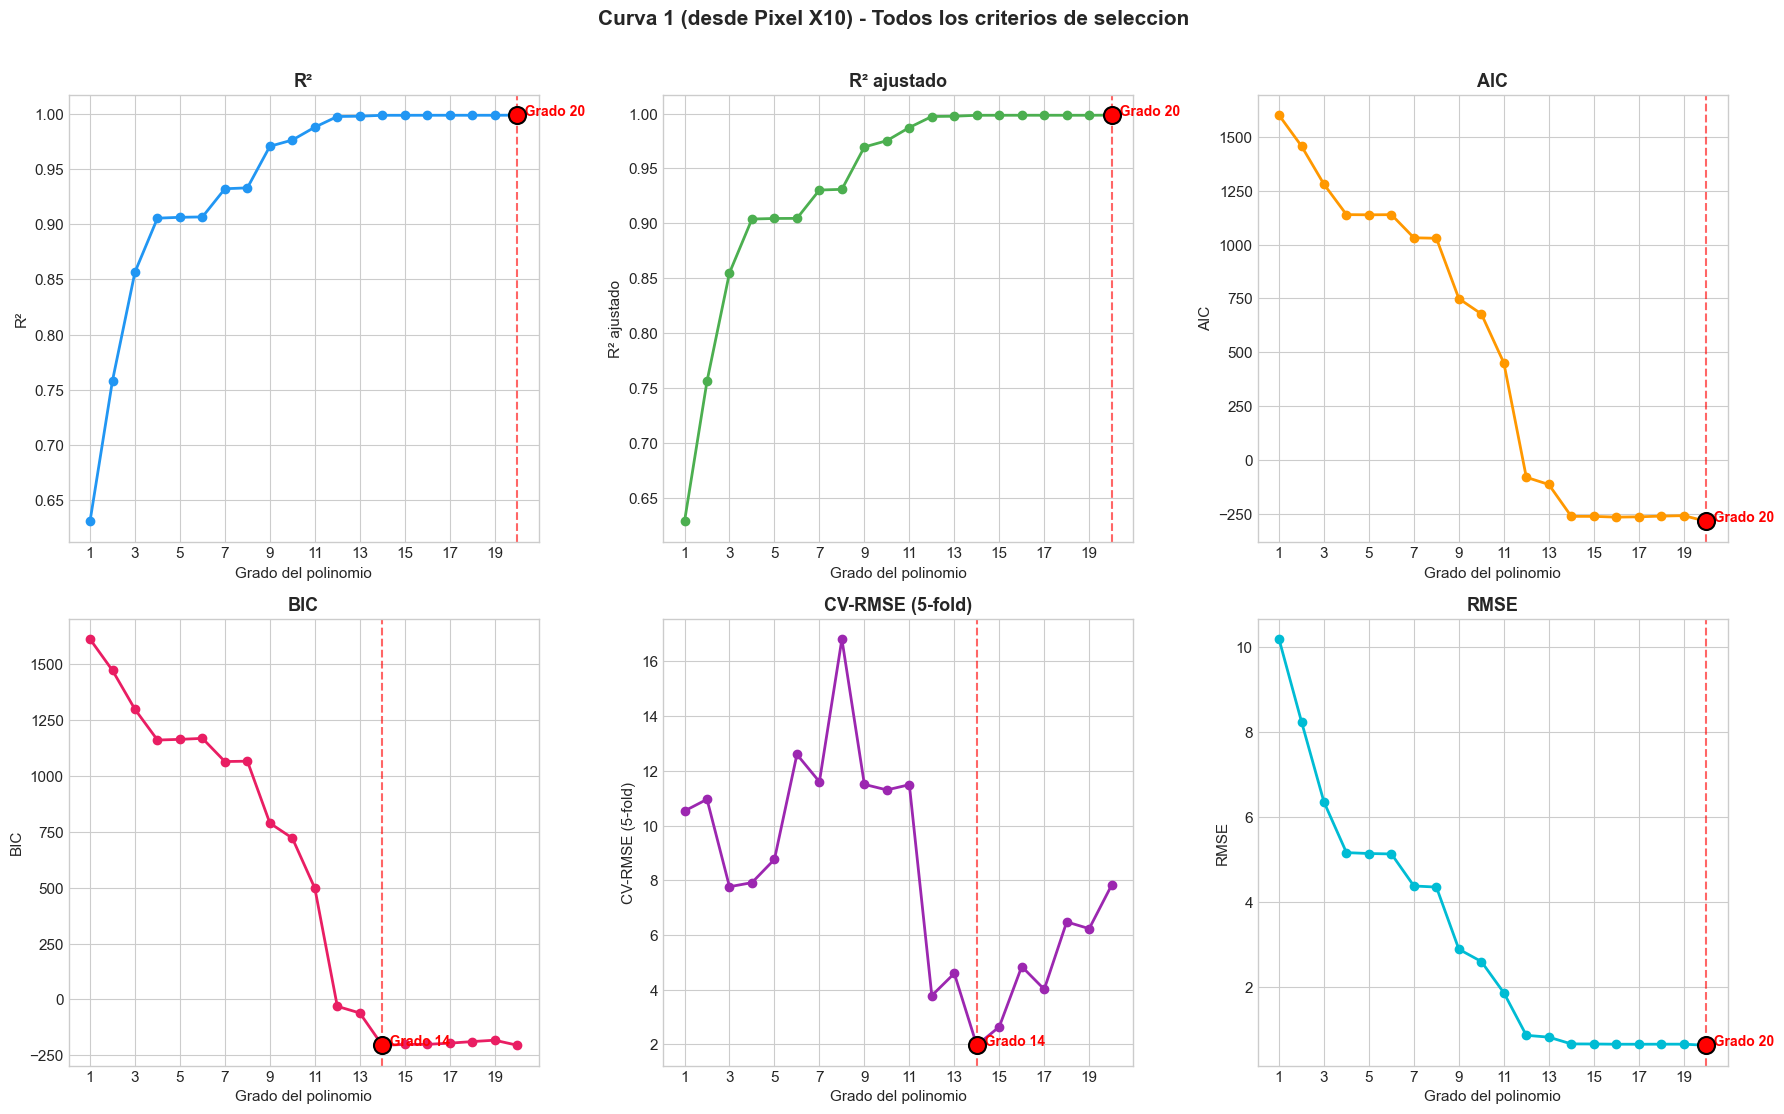

In [4]:
# Visualizacion de los 5 criterios
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

criterios = [
    ('r2', 'R²', 'max', C['azul']),
    ('r2_adj', 'R² ajustado', 'max', C['verde']),
    ('aic', 'AIC', 'min', C['naranja']),
    ('bic', 'BIC', 'min', C['rosa']),
    ('cv_rmse', 'CV-RMSE (5-fold)', 'min', C['morado']),
    ('rmse', 'RMSE', 'min', C['cyan'])
]

for i, (col, nombre, modo, color) in enumerate(criterios):
    ax = axes[i // 3, i % 3]
    valores = df_ejemplo[col].values
    
    ax.plot(GRADOS, valores, 'o-', color=color, linewidth=2, markersize=6)
    
    # Marcar optimo
    if modo == 'max':
        idx_opt = np.argmax(valores)
    else:
        idx_opt = np.argmin(valores)
    
    ax.axvline(GRADOS[idx_opt], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.scatter([GRADOS[idx_opt]], [valores[idx_opt]], color='red', s=150, zorder=5,
               edgecolors='black', linewidth=1.5)
    ax.annotate(f'  Grado {GRADOS[idx_opt]}', xy=(GRADOS[idx_opt], valores[idx_opt]),
                fontsize=10, fontweight='bold', color='red')
    
    ax.set_title(nombre)
    ax.set_xlabel('Grado del polinomio')
    ax.set_ylabel(nombre)
    ax.set_xticks(GRADOS[::2])

fig.suptitle(f'Curva {CID} (desde Pixel X{XVAL}) - Todos los criterios de seleccion',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# Tabla completa de metricas por grado
tabla = df_ejemplo[['grado', 'r2', 'r2_adj', 'aic', 'bic', 'cv_rmse', 'rmse', 'mae']].copy()
tabla.columns = ['Grado', 'R2', 'R2 adj', 'AIC', 'BIC', 'CV-RMSE', 'RMSE', 'MAE']

# Resaltar optimos
print(f'Curva {CID} desde Pixel X{XVAL} - Tabla de metricas por grado\n')
print(tabla.to_string(index=False, float_format='{:.6f}'.format))
print()
print('Los valores resaltados (optimos) por criterio:')
print(f'  R2 adj max:  grado {opt_r2_adj} -> {df_ejemplo.loc[df_ejemplo["r2_adj"].idxmax(), "r2_adj"]:.6f}')
print(f'  AIC min:     grado {opt_aic} -> {df_ejemplo.loc[df_ejemplo["aic"].idxmin(), "aic"]:.2f}')
print(f'  BIC min:     grado {opt_bic} -> {df_ejemplo.loc[df_ejemplo["bic"].idxmin(), "bic"]:.2f}')
print(f'  CV-RMSE min: grado {opt_cv} -> {df_ejemplo.loc[df_ejemplo["cv_rmse"].idxmin(), "cv_rmse"]:.6f}')

Curva 1 desde Pixel X10 - Tabla de metricas por grado

 Grado       R2   R2 adj         AIC         BIC   CV-RMSE      RMSE      MAE
     1 0.631012 0.628848 1601.596455 1609.277738 10.532378 10.196942 7.390137
     2 0.758419 0.756288 1457.891564 1469.413489 10.959710  8.250778 6.507822
     3 0.856643 0.854952 1280.369268 1295.731834  7.764749  6.355839 5.090357
     4 0.905372 0.903972 1139.478635 1158.681844  7.915256  5.163858 4.020669
     5 0.906147 0.904476 1138.649895 1161.693745  8.765280  5.142671 4.096539
     6 0.906512 0.904565 1139.307333 1166.191825 12.598878  5.132645 4.050674
     7 0.931989 0.930365 1031.858799 1062.583932 11.601284  4.377768 3.756593
     8 0.932812 0.931002 1029.670578 1064.236353 16.812743  4.351199 3.673821
     9 0.970440 0.969552  749.226062  787.632478 11.504860  2.886145 2.566289
    10 0.976090 0.975298  678.252008  720.499066 11.302179  2.595696 2.133434
    11 0.987728 0.987283  450.812912  496.900612 11.493204  1.859612 1.603688
    12 0.

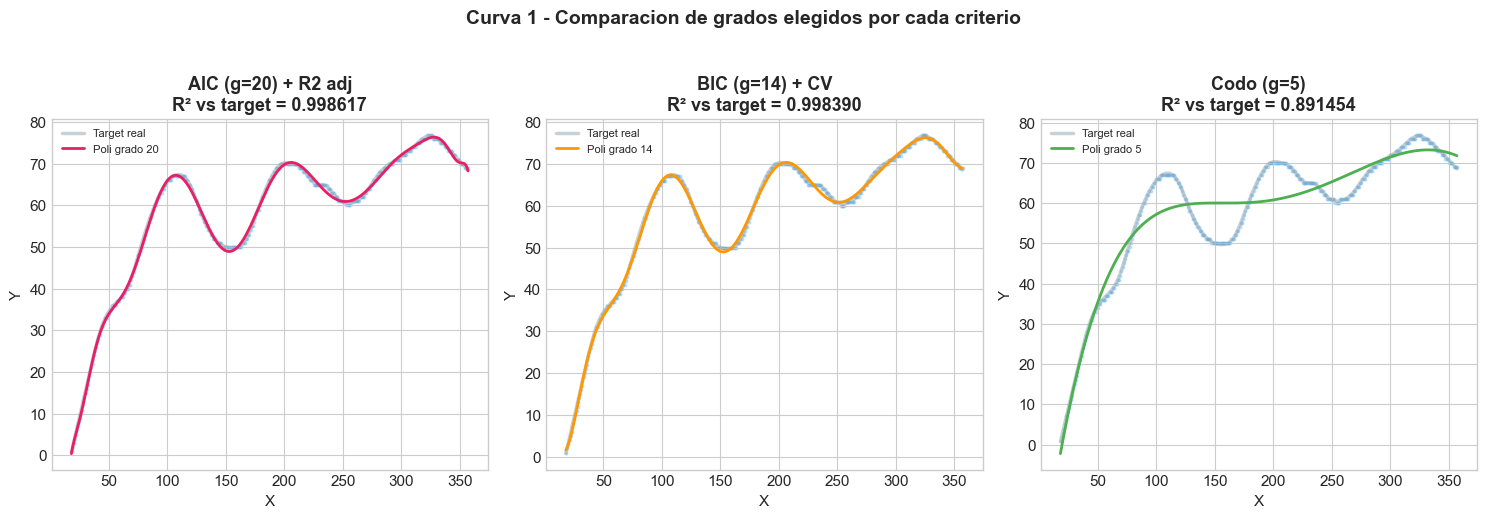

In [6]:
# Visualizacion: como se ve el ajuste en el grado que cada criterio elige
grados_elegidos = {
    f'BIC (g={opt_bic})': int(opt_bic),
    f'AIC (g={opt_aic})': int(opt_aic),
    f'R2 adj (g={opt_r2_adj})': int(opt_r2_adj),
    f'CV (g={opt_cv})': int(opt_cv),
    f'Codo (g={opt_elbow})': int(opt_elbow),
}

# Eliminar duplicados manteniendo orden
grados_unicos = {}
for nombre, g in grados_elegidos.items():
    if g not in grados_unicos.values():
        grados_unicos[nombre] = g
    else:
        # Agregar al nombre existente
        for k, v in grados_unicos.items():
            if v == g:
                nuevo_k = k + ' + ' + nombre.split('(')[0].strip()
                grados_unicos[nuevo_k] = grados_unicos.pop(k)
                break

n_plots = len(grados_unicos)
fig, axes = plt.subplots(1, min(n_plots, 4), figsize=(5 * min(n_plots, 4), 5))
if n_plots == 1:
    axes = [axes]

idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
xs_t, ys_t = tx[idx_t], ty[idx_t]

colores_crit = [C['rosa'], C['naranja'], C['verde'], C['morado'], C['cyan']]

for i, (nombre, g) in enumerate(list(grados_unicos.items())[:4]):
    ax = axes[i]
    
    coeffs = np.polyfit(mx, my, g)
    y_poli = np.poly1d(coeffs)(xs_t)
    r2_vs_target = r2_score(ys_t, y_poli)
    
    ax.plot(xs_t, ys_t, color=C['gris'], linewidth=2.5, alpha=0.5, label='Target real')
    ax.scatter(mx, my, color=C['azul'], s=4, alpha=0.2, zorder=0)
    ax.plot(xs_t, y_poli, color=colores_crit[i], linewidth=2, label=f'Poli grado {g}')
    
    ax.set_title(f'{nombre}\nR² vs target = {r2_vs_target:.6f}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(fontsize=8)

fig.suptitle(f'Curva {CID} - Comparacion de grados elegidos por cada criterio',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Que nos dice esto?

- **BIC** suele ser el mas conservador (elige grados mas bajos). Prefiere simplicidad.
- **AIC** es un poco mas permisivo que BIC.
- **R² ajustado** tiende a coincidir con AIC o elegir algo ligeramente mas alto.
- **CV-RMSE** es el criterio mas practico: mide directamente si el modelo generaliza.
- **El codo** es util como referencia rapida pero es mas subjetivo.

En la practica, si **BIC y AIC coinciden**, ese grado es bastante confiable. Si difieren, la zona entre ambos es la "zona segura".

---

## 4. Barrido masivo: 500 curvas x 5 escalas

Ahora si, vamos a calcular las metricas para **todas las curvas**. Para cada una de las 500 curvas y cada una de las 5 escalas pixel, ajustamos polinomios de grado 1 a 20 y registramos AIC, BIC, R² ajustado y RMSE.

La validacion cruzada es mas costosa, asi que la hacemos sobre una muestra representativa de 50 curvas.

In [7]:
# ============================================================
# BARRIDO PRINCIPAL: 500 curvas x 5 escalas x 20 grados
# ============================================================
GRADOS = list(range(1, 21))
N_SAMPLE_TARGET = 1000  # submuestreo del target para evaluar R2 vs target

all_results = []

for cid in range(1, 501):
    # Target (para comparar)
    tx, ty = load_target(cid)
    idx_t = np.linspace(0, len(tx)-1, N_SAMPLE_TARGET).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    
    for xval in XVALS:
        px, py = load_pixel(cid, xval)
        mx, my = pixel_to_target(px, py, xval)
        
        for deg in GRADOS:
            # Ajustar sobre pixel mapeado
            res = fit_and_evaluate(mx, my, deg)
            
            # Evaluar contra target real
            y_poli_en_target = np.poly1d(res['coeffs'])(xs_t)
            r2_vs_target = r2_score(ys_t, y_poli_en_target)
            rmse_vs_target = np.sqrt(mean_squared_error(ys_t, y_poli_en_target))
            
            all_results.append({
                'curva': cid,
                'escala': f'X{xval}',
                'xval': xval,
                'grado': deg,
                'r2_pixel': res['r2'],
                'r2_adj': res['r2_adj'],
                'aic': res['aic'],
                'bic': res['bic'],
                'rmse_pixel': res['rmse'],
                'r2_vs_target': r2_vs_target,
                'rmse_vs_target': rmse_vs_target
            })
    
    if cid % 100 == 0:
        print(f'  Procesadas {cid}/500 curvas...')

df_all = pd.DataFrame(all_results)
print(f'\nBarrido completo: {len(df_all):,} combinaciones evaluadas')
print(f'  500 curvas x 5 escalas x {len(GRADOS)} grados = {500*5*len(GRADOS):,}')

  Procesadas 100/500 curvas...
  Procesadas 200/500 curvas...
  Procesadas 300/500 curvas...
  Procesadas 400/500 curvas...
  Procesadas 500/500 curvas...

Barrido completo: 50,000 combinaciones evaluadas
  500 curvas x 5 escalas x 20 grados = 50,000


In [8]:
# Validacion cruzada en muestra representativa (50 curvas)
np.random.seed(42)
curvas_cv = np.random.choice(range(1, 501), size=50, replace=False)
curvas_cv.sort()

cv_results = []

for cid in curvas_cv:
    for xval in XVALS:
        px, py = load_pixel(cid, xval)
        mx, my = pixel_to_target(px, py, xval)
        
        for deg in GRADOS:
            cv_err = cv_rmse(mx, my, deg, k=5)
            cv_results.append({
                'curva': cid, 'escala': f'X{xval}',
                'grado': deg, 'cv_rmse': cv_err
            })
    
    if cid == curvas_cv[24]:
        print(f'  CV: 25/50 curvas procesadas...')

df_cv = pd.DataFrame(cv_results)
print(f'Validacion cruzada completa: {len(df_cv):,} evaluaciones ({len(curvas_cv)} curvas)')

  CV: 25/50 curvas procesadas...
Validacion cruzada completa: 5,000 evaluaciones (50 curvas)


---

## 5. Tabla maestra de grados optimos

Ahora extraemos el grado optimo para **cada curva** segun cada criterio. Esto es el resultado central de este notebook.

In [9]:
# ============================================================
# TABLA MAESTRA: grado optimo por curva, escala y criterio
# ============================================================

def get_optimal_degrees(df, cid, escala):
    """Extrae el grado optimo por cada criterio para una curva/escala."""
    sub = df[(df['curva'] == cid) & (df['escala'] == escala)].copy()
    
    if len(sub) == 0:
        return None
    
    # R2 ajustado: maximo
    g_r2adj = int(sub.loc[sub['r2_adj'].idxmax(), 'grado'])
    
    # AIC: minimo
    g_aic = int(sub.loc[sub['aic'].idxmin(), 'grado'])
    
    # BIC: minimo
    g_bic = int(sub.loc[sub['bic'].idxmin(), 'grado'])
    
    # RMSE vs target: minimo
    g_rmse = int(sub.loc[sub['rmse_vs_target'].idxmin(), 'grado'])
    
    # Codo: delta R2 < 0.001
    r2_vals = sub.sort_values('grado')['r2_vs_target'].values
    g_elbow = GRADOS[find_elbow(r2_vals, threshold=0.001)]
    
    # R2 vs target en cada grado optimo
    r2_at_bic = float(sub[sub['grado'] == g_bic]['r2_vs_target'].values[0])
    r2_at_aic = float(sub[sub['grado'] == g_aic]['r2_vs_target'].values[0])
    rmse_at_bic = float(sub[sub['grado'] == g_bic]['rmse_vs_target'].values[0])
    
    return {
        'curva': cid, 'escala': escala,
        'g_r2adj': g_r2adj, 'g_aic': g_aic, 'g_bic': g_bic,
        'g_rmse_min': g_rmse, 'g_codo': g_elbow,
        'r2_at_bic': r2_at_bic, 'r2_at_aic': r2_at_aic,
        'rmse_at_bic': rmse_at_bic
    }

# Calcular para todas las curvas y escalas
tabla_maestra = []
for cid in range(1, 501):
    for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
        row = get_optimal_degrees(df_all, cid, escala)
        if row:
            tabla_maestra.append(row)

df_master = pd.DataFrame(tabla_maestra)
print(f'Tabla maestra: {len(df_master)} filas (500 curvas x 5 escalas)')
print()
print(df_master.head(10).to_string(index=False))

Tabla maestra: 2500 filas (500 curvas x 5 escalas)

 curva escala  g_r2adj  g_aic  g_bic  g_rmse_min  g_codo  r2_at_bic  r2_at_aic  rmse_at_bic
     1    X10       20     20     14          20       8   0.998390   0.998617     0.639688
     1    X15       20     20     20          20       8   0.998509   0.998509     0.615548
     1    X18       20     20     20          20       8   0.998203   0.998203     0.675784
     1    X21       20     20     20          20       8   0.997977   0.997977     0.716938
     1    X25       16     16     16          20       8   0.997403   0.997403     0.812327
     2    X10       20     15     15          20      14   0.988118   0.988118     1.609661
     2    X15       20     20     16          20      14   0.988520   0.989175     1.582161
     2    X18       20     20     15          20      14   0.988301   0.988815     1.597202
     2    X21       20     20     15          20      14   0.987970   0.988503     1.619617
     2    X25       20     2

In [10]:
# Agregar CV optimo para las curvas que tienen datos de CV
cv_optimal = []
for cid in curvas_cv:
    for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
        sub = df_cv[(df_cv['curva'] == cid) & (df_cv['escala'] == escala)]
        if len(sub) > 0:
            g_cv = int(sub.loc[sub['cv_rmse'].idxmin(), 'grado'])
            cv_optimal.append({'curva': cid, 'escala': escala, 'g_cv': g_cv})

df_cv_opt = pd.DataFrame(cv_optimal)

# Comparar CV con otros criterios
df_comp_cv = df_master[df_master['curva'].isin(curvas_cv)].merge(
    df_cv_opt, on=['curva', 'escala'], how='left'
)

print('Concordancia entre criterios (en las 50 curvas con CV):')
print(f'  CV coincide con BIC:     {(df_comp_cv["g_cv"] == df_comp_cv["g_bic"]).mean():.1%}')
print(f'  CV coincide con AIC:     {(df_comp_cv["g_cv"] == df_comp_cv["g_aic"]).mean():.1%}')
print(f'  CV coincide con R2 adj:  {(df_comp_cv["g_cv"] == df_comp_cv["g_r2adj"]).mean():.1%}')
print(f'  |CV - BIC| <= 1:         {(np.abs(df_comp_cv["g_cv"] - df_comp_cv["g_bic"]) <= 1).mean():.1%}')
print(f'  |CV - AIC| <= 1:         {(np.abs(df_comp_cv["g_cv"] - df_comp_cv["g_aic"]) <= 1).mean():.1%}')
print()
print('Grado promedio por criterio (50 curvas, todas las escalas):')
print(f'  BIC:     {df_comp_cv["g_bic"].mean():.1f} +/- {df_comp_cv["g_bic"].std():.1f}')
print(f'  AIC:     {df_comp_cv["g_aic"].mean():.1f} +/- {df_comp_cv["g_aic"].std():.1f}')
print(f'  R2 adj:  {df_comp_cv["g_r2adj"].mean():.1f} +/- {df_comp_cv["g_r2adj"].std():.1f}')
print(f'  CV:      {df_comp_cv["g_cv"].mean():.1f} +/- {df_comp_cv["g_cv"].std():.1f}')
print(f'  Codo:    {df_comp_cv["g_codo"].mean():.1f} +/- {df_comp_cv["g_codo"].std():.1f}')

Concordancia entre criterios (en las 50 curvas con CV):
  CV coincide con BIC:     20.4%
  CV coincide con AIC:     16.0%
  CV coincide con R2 adj:  12.4%
  |CV - BIC| <= 1:         35.6%
  |CV - AIC| <= 1:         31.2%

Grado promedio por criterio (50 curvas, todas las escalas):
  BIC:     16.9 +/- 3.4
  AIC:     17.8 +/- 3.0
  R2 adj:  18.1 +/- 2.5
  CV:      13.5 +/- 3.9
  Codo:    8.7 +/- 3.8


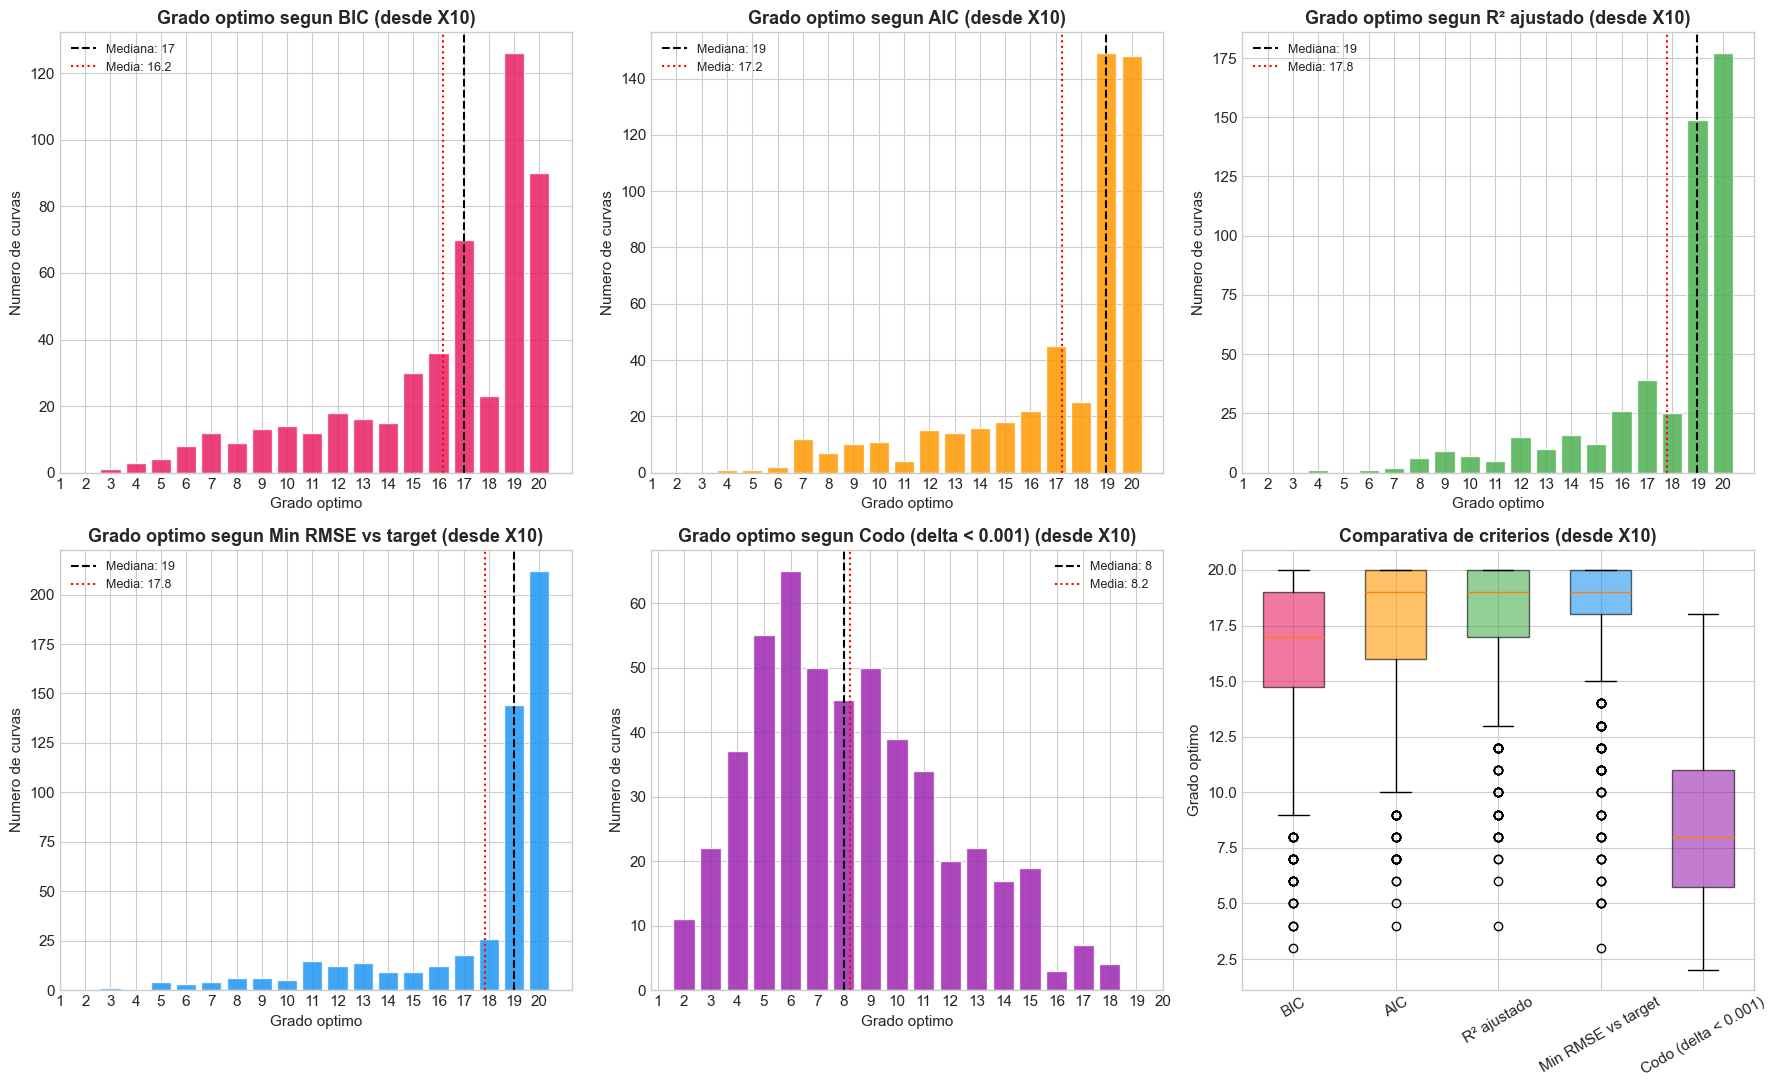

In [11]:
# Distribucion de grados optimos por criterio
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

criterios_plot = [
    ('g_bic', 'BIC', C['rosa']),
    ('g_aic', 'AIC', C['naranja']),
    ('g_r2adj', 'R² ajustado', C['verde']),
    ('g_rmse_min', 'Min RMSE vs target', C['azul']),
    ('g_codo', 'Codo (delta < 0.001)', C['morado']),
]

for i, (col, nombre, color) in enumerate(criterios_plot):
    ax = axes[i // 3, i % 3]
    
    # Histograma usando X10 (caso mas dificil)
    sub = df_master[df_master['escala'] == 'X10']
    counts = sub[col].value_counts().sort_index()
    
    ax.bar(counts.index, counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(sub[col].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mediana: {sub[col].median():.0f}')
    ax.axvline(sub[col].mean(), color='red', linestyle=':', linewidth=1.5,
               label=f'Media: {sub[col].mean():.1f}')
    
    ax.set_title(f'Grado optimo segun {nombre} (desde X10)')
    ax.set_xlabel('Grado optimo')
    ax.set_ylabel('Numero de curvas')
    ax.set_xticks(range(1, 21))
    ax.legend(fontsize=9)

# Panel 6: boxplots comparativos
ax = axes[1, 2]
sub_x10 = df_master[df_master['escala'] == 'X10']
data_bp = [sub_x10[c].values for c, _, _ in criterios_plot]
nombres_bp = [n for _, n, _ in criterios_plot]
colores_bp = [c for _, _, c in criterios_plot]

bp = ax.boxplot(data_bp, labels=nombres_bp, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colores_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Grado optimo')
ax.set_title('Comparativa de criterios (desde X10)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [12]:
# Tabla resumen compacta: grado optimo por escala y criterio (todas las curvas)
print('=' * 80)
print('RESUMEN: Grado optimo promedio por escala y criterio (500 curvas)')
print('=' * 80)
print()

resumen_escalas = []
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    sub = df_master[df_master['escala'] == escala]
    row = {
        'Escala': escala,
        'BIC (media)': f"{sub['g_bic'].mean():.1f}",
        'BIC (mediana)': f"{sub['g_bic'].median():.0f}",
        'AIC (media)': f"{sub['g_aic'].mean():.1f}",
        'AIC (mediana)': f"{sub['g_aic'].median():.0f}",
        'R2adj (media)': f"{sub['g_r2adj'].mean():.1f}",
        'Codo (media)': f"{sub['g_codo'].mean():.1f}",
        'R2 en BIC': f"{sub['r2_at_bic'].mean():.4f}",
        'RMSE en BIC': f"{sub['rmse_at_bic'].mean():.4f}",
    }
    resumen_escalas.append(row)

df_resumen = pd.DataFrame(resumen_escalas)
print(df_resumen.to_string(index=False))
print()
print('Interpretacion:')
print('  - BIC es el mas conservador (grados mas bajos)')
print('  - AIC y R2 ajustado suelen coincidir')
print('  - Escalas mayores (X25) tienden a necesitar grados ligeramente mas altos')
print('    porque tienen mas puntos y el criterio puede permitirse mas complejidad')

RESUMEN: Grado optimo promedio por escala y criterio (500 curvas)

Escala BIC (media) BIC (mediana) AIC (media) AIC (mediana) R2adj (media) Codo (media) R2 en BIC RMSE en BIC
   X10        16.2            17        17.2            19          17.8          8.2    0.9976      0.5930
   X15        17.0            19        17.9            19          18.2          8.2    0.9975      0.5956
   X18        17.3            19        18.0            19          18.4          8.2    0.9969      0.6663
   X21        17.5            19        18.2            20          18.6          8.2    0.9963      0.7282
   X25        17.8            19        18.4            20          18.7          8.2    0.9957      0.7944

Interpretacion:
  - BIC es el mas conservador (grados mas bajos)
  - AIC y R2 ajustado suelen coincidir
  - Escalas mayores (X25) tienden a necesitar grados ligeramente mas altos
    porque tienen mas puntos y el criterio puede permitirse mas complejidad


In [13]:
# ============================================================
# TABLA DE GRADOS POR CURVA (el entregable principal)
# ============================================================

# Tomamos BIC como criterio principal (conservador y confiable)
# y AIC como criterio secundario

# Para cada curva: grado BIC y AIC en cada escala, R2 logrado, y promedios
tabla_por_curva = []

for cid in range(1, 501):
    row = {'curva': cid}
    
    grados_bic = []
    grados_aic = []
    r2s = []
    
    for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
        sub = df_master[(df_master['curva'] == cid) & (df_master['escala'] == escala)]
        if len(sub) > 0:
            s = sub.iloc[0]
            row[f'bic_{escala}'] = int(s['g_bic'])
            row[f'aic_{escala}'] = int(s['g_aic'])
            row[f'r2_{escala}'] = round(s['r2_at_bic'], 4)
            grados_bic.append(int(s['g_bic']))
            grados_aic.append(int(s['g_aic']))
            r2s.append(s['r2_at_bic'])
    
    row['bic_promedio'] = round(np.mean(grados_bic), 1)
    row['aic_promedio'] = round(np.mean(grados_aic), 1)
    row['bic_max'] = max(grados_bic)
    row['r2_promedio'] = round(np.mean(r2s), 4)
    row['r2_min'] = round(min(r2s), 4)
    
    # Clasificacion de dificultad
    bic_max = max(grados_bic)
    if bic_max <= 5:
        row['dificultad'] = 'facil'
    elif bic_max <= 10:
        row['dificultad'] = 'media'
    elif bic_max <= 15:
        row['dificultad'] = 'dificil'
    else:
        row['dificultad'] = 'muy_dificil'
    
    tabla_por_curva.append(row)

df_curvas = pd.DataFrame(tabla_por_curva)

print(f'Tabla por curva: {len(df_curvas)} curvas')
print()
print('Distribucion de dificultad:')
dif_counts = df_curvas['dificultad'].value_counts()
for d in ['facil', 'media', 'dificil', 'muy_dificil']:
    n = dif_counts.get(d, 0)
    print(f'  {d:>15}: {n:>4} curvas ({n/500:.1%})')

print()
print('Primeras 20 curvas:')
cols_show = ['curva', 'bic_X10', 'bic_X15', 'bic_X18', 'bic_X21', 'bic_X25',
             'bic_promedio', 'r2_promedio', 'dificultad']
print(df_curvas[cols_show].head(20).to_string(index=False))

Tabla por curva: 500 curvas

Distribucion de dificultad:
            facil:    0 curvas (0.0%)
            media:   25 curvas (5.0%)
          dificil:   60 curvas (12.0%)
      muy_dificil:  415 curvas (83.0%)

Primeras 20 curvas:
 curva  bic_X10  bic_X15  bic_X18  bic_X21  bic_X25  bic_promedio  r2_promedio  dificultad
     1       14       20       20       20       16          18.0       0.9981 muy_dificil
     2       15       16       15       15       16          15.4       0.9881 muy_dificil
     3       15       15       16       16       16          15.6       0.9993 muy_dificil
     4       12       11       13       12       13          12.2       0.9991     dificil
     5       19       19       20       20       20          19.6       0.9977 muy_dificil
     6       15       14       14       14       16          14.6       0.9997 muy_dificil
     7        7        7        9       10        9           8.4       0.9997       media
     8       18       20       20       

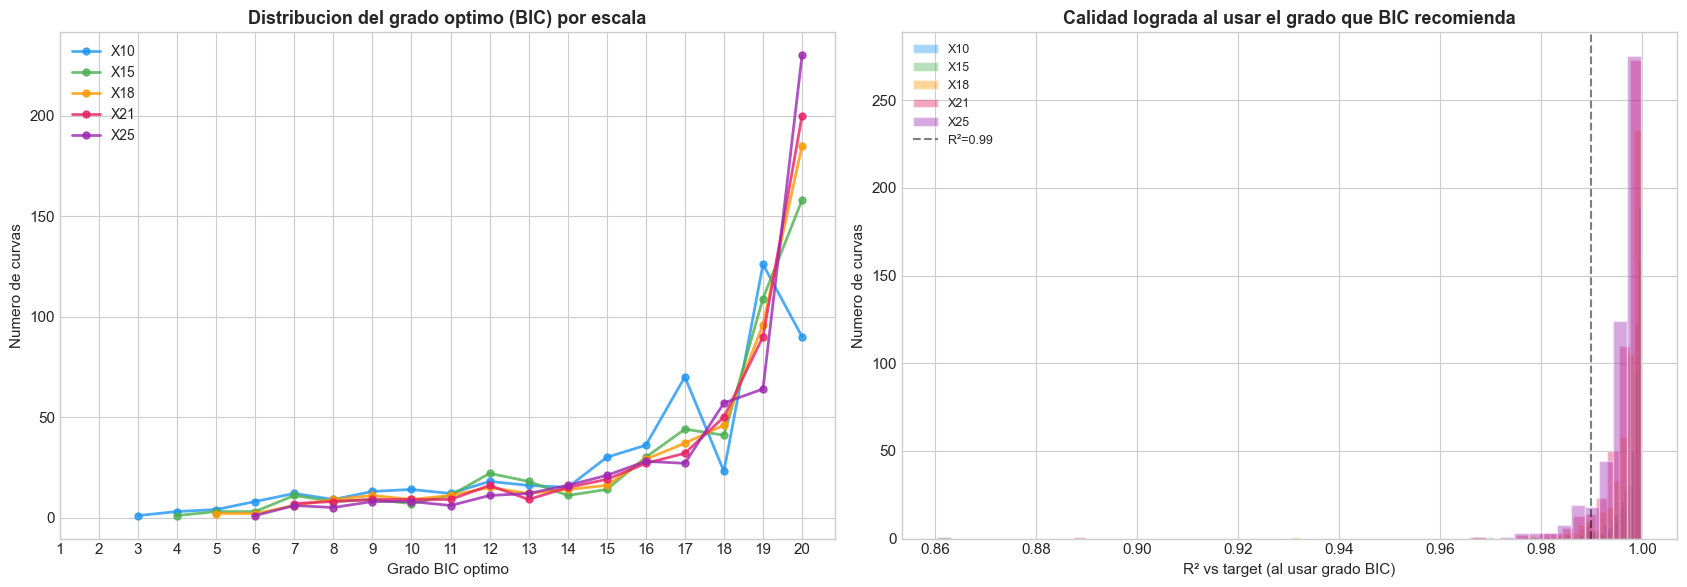

R² vs target logrado con grado BIC (500 curvas):
  X10: media=0.9976, mediana=0.9990, >0.99: 95.0%, >0.95: 100.0%
  X15: media=0.9975, mediana=0.9989, >0.99: 94.8%, >0.95: 100.0%
  X18: media=0.9969, mediana=0.9984, >0.99: 93.8%, >0.95: 99.8%
  X21: media=0.9963, mediana=0.9980, >0.99: 92.6%, >0.95: 99.8%
  X25: media=0.9957, mediana=0.9974, >0.99: 91.0%, >0.95: 99.8%


In [14]:
# Visualizacion: distribucion de grado BIC por escala (las 500 curvas)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Panel izquierdo: histograma apilado
ax = axes[0]
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    col = f'bic_{escala}'
    counts = df_curvas[col].value_counts().sort_index()
    ax.plot(counts.index, counts.values, 'o-', color=SCALE_COLORS[escala],
            linewidth=2, markersize=5, label=escala, alpha=0.8)

ax.set_xlabel('Grado BIC optimo')
ax.set_ylabel('Numero de curvas')
ax.set_title('Distribucion del grado optimo (BIC) por escala')
ax.legend(fontsize=10)
ax.set_xticks(range(1, 21))

# Panel derecho: R2 logrado al usar grado BIC
ax = axes[1]
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    col = f'r2_{escala}'
    ax.hist(df_curvas[col].dropna(), bins=50, alpha=0.4,
            color=SCALE_COLORS[escala], label=escala, edgecolor='white')

ax.set_xlabel('R² vs target (al usar grado BIC)')
ax.set_ylabel('Numero de curvas')
ax.set_title('Calidad lograda al usar el grado que BIC recomienda')
ax.axvline(0.99, color='black', linestyle='--', alpha=0.5, label='R²=0.99')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Estadisticas de R2 logrado
print('R² vs target logrado con grado BIC (500 curvas):')
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    col = f'r2_{escala}'
    vals = df_curvas[col].dropna()
    pct_above_99 = (vals >= 0.99).mean()
    pct_above_95 = (vals >= 0.95).mean()
    print(f'  {escala}: media={vals.mean():.4f}, mediana={vals.median():.4f}, '
          f'>0.99: {pct_above_99:.1%}, >0.95: {pct_above_95:.1%}')

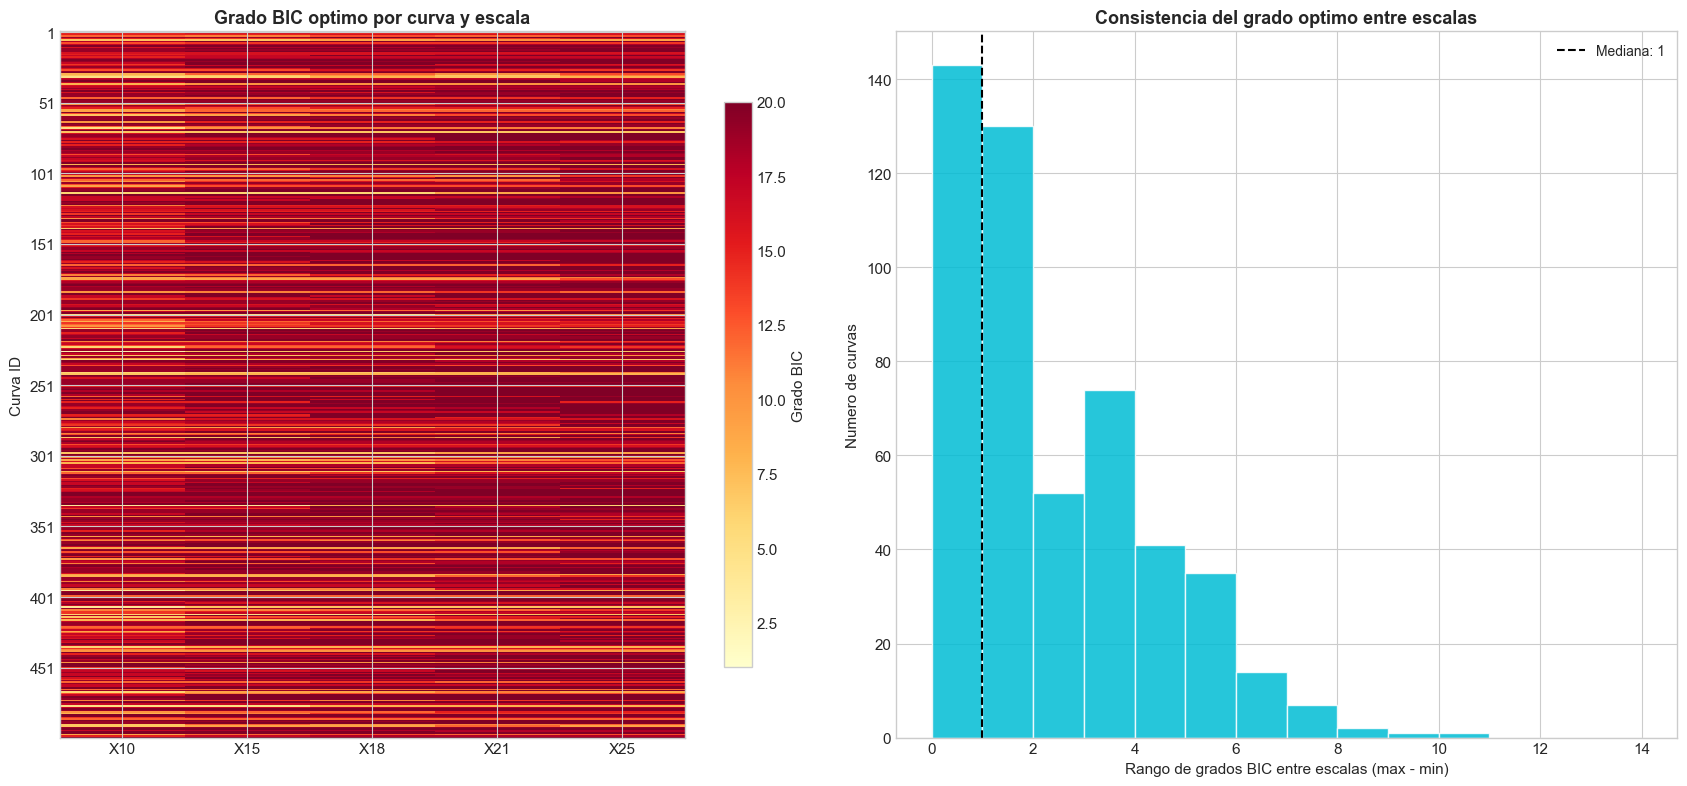

Consistencia entre escalas (rango max-min de grado BIC):
  Rango 0 (perfecto acuerdo): 143 curvas (28.6%)
  Rango <= 2: 325 curvas (65.0%)
  Rango <= 4: 440 curvas (88.0%)


In [15]:
# Mapa de calor: grado BIC para todas las curvas
# Agrupamos curvas en bloques para que sea legible

# Version compacta: heatmap de grado BIC por curva (eje Y) y escala (eje X)
pivot_bic = df_master[['curva', 'escala', 'g_bic']].pivot(
    index='curva', columns='escala', values='g_bic'
).reindex(columns=['X10', 'X15', 'X18', 'X21', 'X25'])

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Panel izquierdo: heatmap completo
im = axes[0].imshow(pivot_bic.values, aspect='auto', cmap='YlOrRd',
                     vmin=1, vmax=20, interpolation='nearest')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['X10', 'X15', 'X18', 'X21', 'X25'])
axes[0].set_ylabel('Curva ID')
axes[0].set_title('Grado BIC optimo por curva y escala')
axes[0].set_yticks(np.arange(0, 500, 50))
axes[0].set_yticklabels(np.arange(1, 501, 50))
plt.colorbar(im, ax=axes[0], label='Grado BIC', shrink=0.8)

# Panel derecho: consistencia entre escalas
# Diferencia entre grado max y min entre escalas para cada curva
rango_grados = pivot_bic.max(axis=1) - pivot_bic.min(axis=1)
axes[1].hist(rango_grados, bins=range(0, 15), color=C['cyan'],
             edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Rango de grados BIC entre escalas (max - min)')
axes[1].set_ylabel('Numero de curvas')
axes[1].set_title('Consistencia del grado optimo entre escalas')
axes[1].axvline(rango_grados.median(), color='black', linestyle='--',
                label=f'Mediana: {rango_grados.median():.0f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Consistencia entre escalas (rango max-min de grado BIC):')
print(f'  Rango 0 (perfecto acuerdo): {(rango_grados == 0).sum()} curvas ({(rango_grados == 0).mean():.1%})')
print(f'  Rango <= 2: {(rango_grados <= 2).sum()} curvas ({(rango_grados <= 2).mean():.1%})')
print(f'  Rango <= 4: {(rango_grados <= 4).sum()} curvas ({(rango_grados <= 4).mean():.1%})')

In [16]:
# Guardar tabla maestra como CSV
df_curvas.to_csv('grados_optimos_por_curva.csv', index=False)
print('Tabla guardada: grados_optimos_por_curva.csv')
print(f'  {len(df_curvas)} filas (una por curva)')
print(f'  Columnas: {list(df_curvas.columns)}')

# Tambien guardar la tabla detallada (con todas las metricas)
df_master.to_csv('detalle_criterios_por_curva_escala.csv', index=False)
print(f'\nTabla detallada guardada: detalle_criterios_por_curva_escala.csv')
print(f'  {len(df_master)} filas (500 curvas x 5 escalas)')

Tabla guardada: grados_optimos_por_curva.csv
  500 filas (una por curva)
  Columnas: ['curva', 'bic_X10', 'aic_X10', 'r2_X10', 'bic_X15', 'aic_X15', 'r2_X15', 'bic_X18', 'aic_X18', 'r2_X18', 'bic_X21', 'aic_X21', 'r2_X21', 'bic_X25', 'aic_X25', 'r2_X25', 'bic_promedio', 'aic_promedio', 'bic_max', 'r2_promedio', 'r2_min', 'dificultad']

Tabla detallada guardada: detalle_criterios_por_curva_escala.csv
  2500 filas (500 curvas x 5 escalas)


---

## 6. Que hace dificil una curva?

Ya tenemos el grado optimo para cada curva. Ahora la pregunta interesante: **por que algunas curvas necesitan grado 5 y otras grado 15?**

Vamos a cruzar los grados optimos con las **caracteristicas geometricas** que calculamos en el EDA (curvatura, longitud de arco, numero de extremos, etc.).

In [17]:
# Unir grados optimos con caracteristicas geometricas
df_analysis = df_curvas.merge(df_geo, left_on='curva', right_on='curve_id', how='left')

# Features geometricas a analizar
features = [
    ('arc_length', 'Longitud de arco'),
    ('curvature_mean', 'Curvatura media'),
    ('curvature_max', 'Curvatura maxima'),
    ('n_extrema', 'Num. extremos (max+min)'),
    ('n_inflection', 'Num. puntos inflexion'),
    ('direction_changes', 'Cambios de direccion'),
    ('angle_range', 'Rango de angulos'),
    ('slope_std', 'Desv. est. pendiente'),
]

# Calcular correlacion con grado BIC promedio
print('Correlacion entre caracteristicas geometricas y grado BIC (promedio de escalas):')
print()
correlaciones = []
for feat, nombre in features:
    if feat in df_analysis.columns:
        corr = df_analysis['bic_promedio'].corr(df_analysis[feat])
        correlaciones.append((nombre, feat, corr))
        print(f'  {nombre:>30}: r = {corr:+.3f}')

# Ordenar por correlacion absoluta
correlaciones.sort(key=lambda x: abs(x[2]), reverse=True)
print()
print('Ordenadas por importancia (correlacion absoluta):')
for nombre, feat, corr in correlaciones:
    barra = '#' * int(abs(corr) * 40)
    print(f'  {nombre:>30}: {corr:+.3f}  {barra}')

Correlacion entre caracteristicas geometricas y grado BIC (promedio de escalas):

                Longitud de arco: r = +0.707
                 Curvatura media: r = +0.290
                Curvatura maxima: r = +0.350
         Num. extremos (max+min): r = +0.598
           Num. puntos inflexion: r = +0.663
            Cambios de direccion: r = +0.599
                Rango de angulos: r = +0.464
            Desv. est. pendiente: r = +0.041

Ordenadas por importancia (correlacion absoluta):
                Longitud de arco: +0.707  ############################
           Num. puntos inflexion: +0.663  ##########################
            Cambios de direccion: +0.599  #######################
         Num. extremos (max+min): +0.598  #######################
                Rango de angulos: +0.464  ##################
                Curvatura maxima: +0.350  #############
                 Curvatura media: +0.290  ###########
            Desv. est. pendiente: +0.041  #


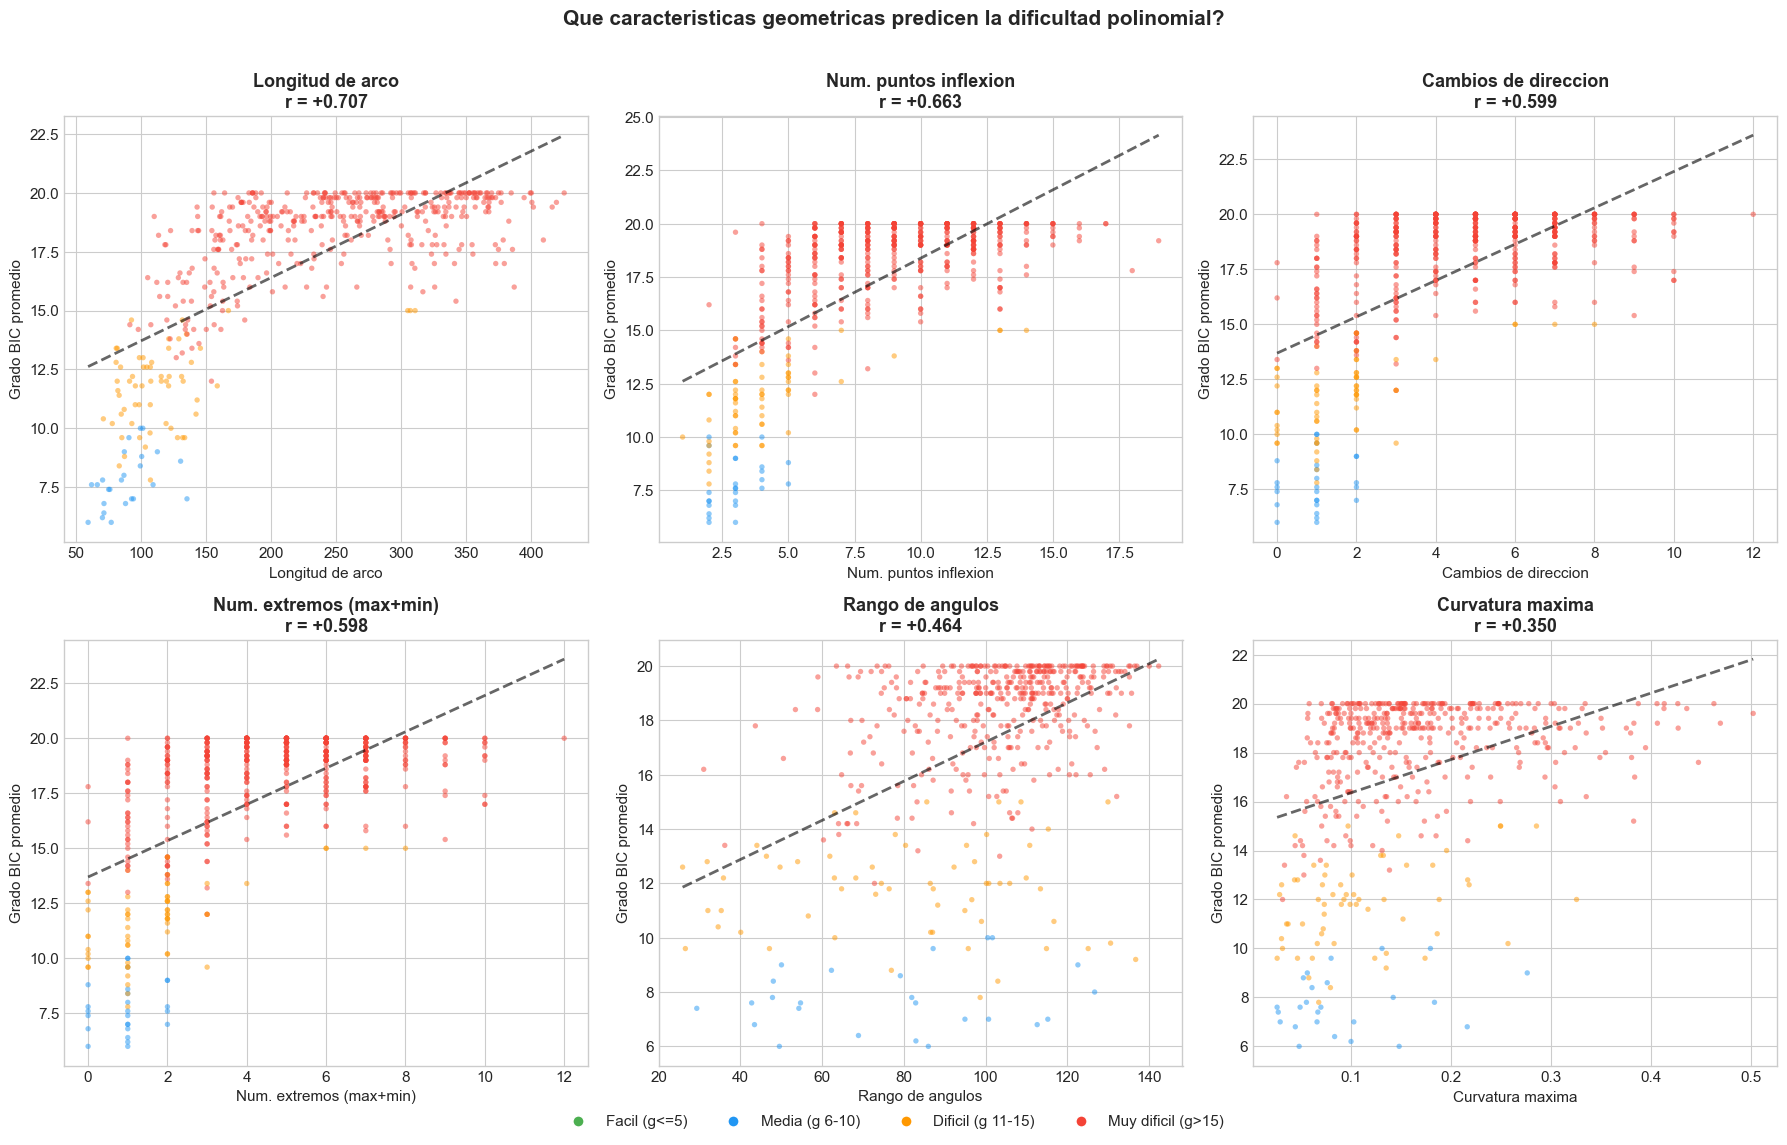

In [18]:
# Scatter plots: features vs grado optimo
top_features = correlaciones[:6]  # top 6 por correlacion

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (nombre, feat, corr) in enumerate(top_features):
    ax = axes[i]
    
    x_vals = df_analysis[feat]
    y_vals = df_analysis['bic_promedio']
    
    # Color por dificultad
    color_map = {'facil': C['verde'], 'media': C['azul'],
                 'dificil': C['naranja'], 'muy_dificil': C['rojo']}
    colors = df_analysis['dificultad'].map(color_map)
    
    ax.scatter(x_vals, y_vals, c=colors, s=15, alpha=0.5, edgecolors='none')
    
    # Linea de tendencia
    z = np.polyfit(x_vals.dropna(), y_vals[x_vals.notna()], 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=2, alpha=0.6)
    
    ax.set_xlabel(nombre)
    ax.set_ylabel('Grado BIC promedio')
    ax.set_title(f'{nombre}\nr = {corr:+.3f}')

# Leyenda comun
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C['verde'], markersize=8, label='Facil (g<=5)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C['azul'], markersize=8, label='Media (g 6-10)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C['naranja'], markersize=8, label='Dificil (g 11-15)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C['rojo'], markersize=8, label='Muy dificil (g>15)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Que caracteristicas geometricas predicen la dificultad polinomial?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Estadisticas por grupo de dificultad
print('=' * 80)
print('Perfil geometrico por nivel de dificultad')
print('=' * 80)
print()

cols_geo = ['arc_length', 'curvature_mean', 'curvature_max', 'n_extrema',
            'n_inflection', 'direction_changes', 'slope_std']

for dif in ['facil', 'media', 'dificil', 'muy_dificil']:
    sub = df_analysis[df_analysis['dificultad'] == dif]
    if len(sub) == 0:
        continue
    print(f'--- {dif.upper()} ({len(sub)} curvas, grado BIC max <= '
          f'{sub["bic_max"].max()})')
    for col in cols_geo:
        if col in sub.columns:
            print(f'  {col:>25}: {sub[col].mean():>10.3f} (std={sub[col].std():.3f})')
    print()

Perfil geometrico por nivel de dificultad

--- MEDIA (25 curvas, grado BIC max <= 10)
                 arc_length:     88.755 (std=19.692)
             curvature_mean:      0.025 (std=0.011)
              curvature_max:      0.095 (std=0.064)
                  n_extrema:      0.960 (std=0.676)
               n_inflection:      3.000 (std=0.957)
          direction_changes:      0.960 (std=0.676)
                  slope_std:      0.714 (std=0.389)

--- DIFICIL (60 curvas, grado BIC max <= 15)
                 arc_length:    118.789 (std=48.771)
             curvature_mean:      0.027 (std=0.010)
              curvature_max:      0.111 (std=0.070)
                  n_extrema:      1.750 (std=1.643)
               n_inflection:      4.183 (std=2.534)
          direction_changes:      1.750 (std=1.643)
                  slope_std:      0.725 (std=0.342)

--- MUY_DIFICIL (415 curvas, grado BIC max <= 20)
                 arc_length:    252.807 (std=77.689)
             curvature_mean:      

---

## 7. Galeria: curvas faciles vs dificiles

Vamos a ver como se ven las curvas de cada categoria. Esto nos ayuda a entender *visualmente* que las hace mas o menos dificiles para un polinomio.

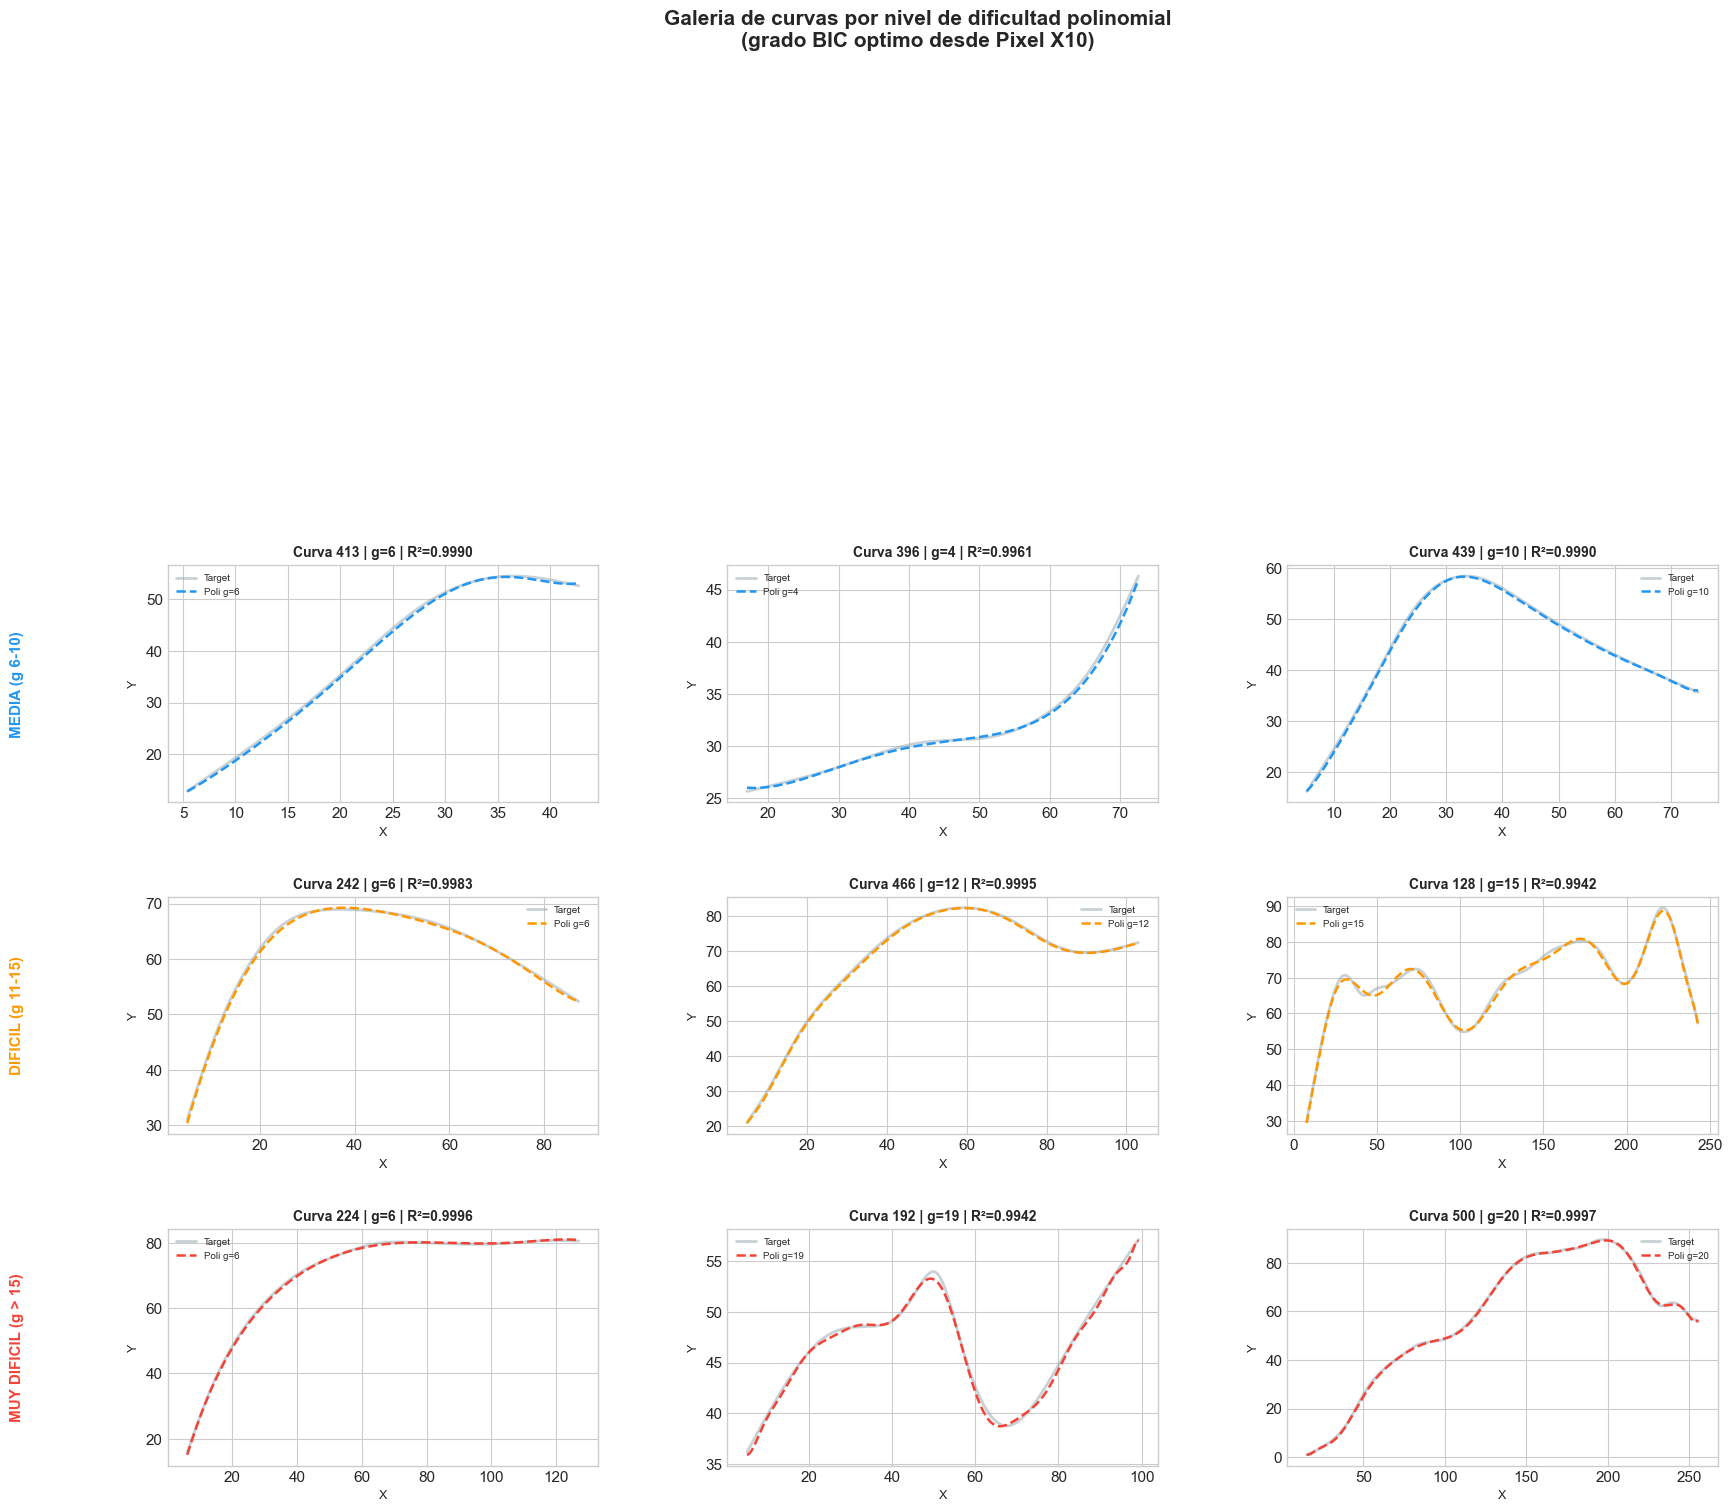

In [20]:
# Galeria por dificultad: 3 ejemplos de cada categoria
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.3)

dificultades = ['facil', 'media', 'dificil', 'muy_dificil']
color_dif = {'facil': C['verde'], 'media': C['azul'],
             'dificil': C['naranja'], 'muy_dificil': C['rojo']}
label_dif = {'facil': 'FACIL (g <= 5)', 'media': 'MEDIA (g 6-10)',
             'dificil': 'DIFICIL (g 11-15)', 'muy_dificil': 'MUY DIFICIL (g > 15)'}

for row_idx, dif in enumerate(dificultades):
    sub = df_analysis[df_analysis['dificultad'] == dif]
    if len(sub) == 0:
        continue
    
    # Seleccionar 3 ejemplos (min, mediana, max grado BIC)
    sorted_sub = sub.sort_values('bic_promedio')
    if len(sorted_sub) >= 3:
        ejemplos = [
            sorted_sub.iloc[0],
            sorted_sub.iloc[len(sorted_sub)//2],
            sorted_sub.iloc[-1]
        ]
    else:
        ejemplos = [sorted_sub.iloc[i] for i in range(len(sorted_sub))]
    
    for col_idx, ej in enumerate(ejemplos[:3]):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        cid = int(ej['curva'])
        
        tx, ty = load_target(cid)
        px, py = load_pixel(cid, 10)
        mx, my = pixel_to_target(px, py, 10)
        
        # Grado BIC de X10
        g = int(ej['bic_X10'])
        coeffs = np.polyfit(mx, my, g)
        
        idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
        xs_t, ys_t = tx[idx_t], ty[idx_t]
        y_poli = np.poly1d(coeffs)(xs_t)
        r2 = r2_score(ys_t, y_poli)
        
        ax.plot(xs_t, ys_t, color=C['gris'], linewidth=2, alpha=0.5, label='Target')
        ax.plot(xs_t, y_poli, color=color_dif[dif], linewidth=1.8,
                linestyle='--', label=f'Poli g={g}')
        
        ax.set_title(f'Curva {cid} | g={g} | R²={r2:.4f}', fontsize=10)
        ax.legend(fontsize=7)
        ax.set_xlabel('X', fontsize=9)
        ax.set_ylabel('Y', fontsize=9)
        
        if col_idx == 0:
            ax.annotate(label_dif[dif], xy=(-0.35, 0.5),
                       xycoords='axes fraction', fontsize=11,
                       fontweight='bold', color=color_dif[dif],
                       rotation=90, va='center', ha='center')

fig.suptitle('Galeria de curvas por nivel de dificultad polinomial\n(grado BIC optimo desde Pixel X10)',
             fontsize=15, fontweight='bold', y=1.02)
plt.show()

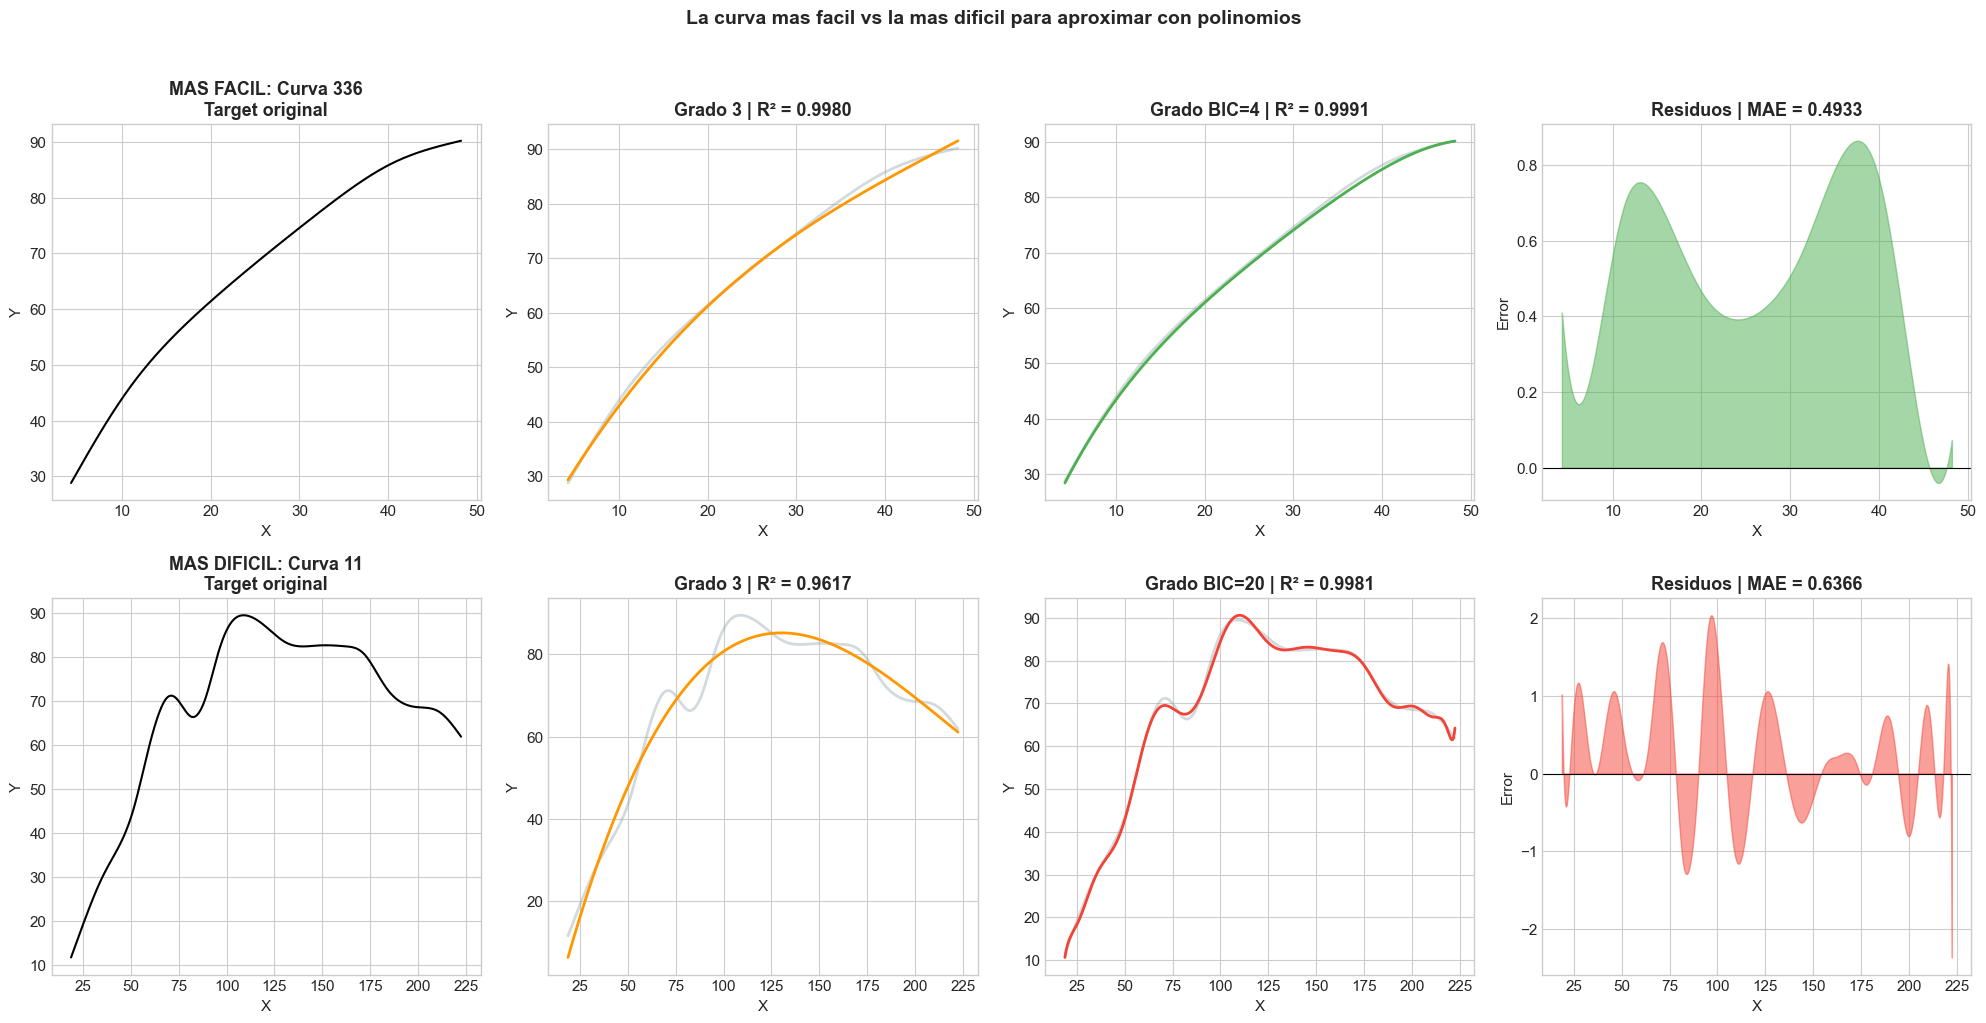

Curva mas facil:   #336 (grado BIC promedio: 6.0)
Curva mas dificil: #11 (grado BIC promedio: 20.0)


In [21]:
# Comparativa detallada: la curva mas facil vs la mas dificil
mas_facil = df_analysis.loc[df_analysis['bic_promedio'].idxmin()]
mas_dificil = df_analysis.loc[df_analysis['bic_promedio'].idxmax()]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row, (info, titulo, color) in enumerate([
    (mas_facil, 'MAS FACIL', C['verde']),
    (mas_dificil, 'MAS DIFICIL', C['rojo'])
]):
    cid = int(info['curva'])
    tx, ty = load_target(cid)
    px, py = load_pixel(cid, 10)
    mx, my = pixel_to_target(px, py, 10)
    
    idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    
    # Col 0: curva original
    axes[row, 0].plot(xs_t, ys_t, color='black', linewidth=1.5)
    axes[row, 0].set_title(f'{titulo}: Curva {cid}\nTarget original')
    axes[row, 0].set_xlabel('X'); axes[row, 0].set_ylabel('Y')
    
    # Col 1: ajuste con grado bajo
    g_low = 3
    c_low = np.polyfit(mx, my, g_low)
    y_low = np.poly1d(c_low)(xs_t)
    r2_low = r2_score(ys_t, y_low)
    axes[row, 1].plot(xs_t, ys_t, color=C['gris'], linewidth=2, alpha=0.4)
    axes[row, 1].plot(xs_t, y_low, color=C['naranja'], linewidth=2)
    axes[row, 1].set_title(f'Grado 3 | R² = {r2_low:.4f}')
    axes[row, 1].set_xlabel('X'); axes[row, 1].set_ylabel('Y')
    
    # Col 2: ajuste con grado BIC
    g_bic = int(info['bic_X10'])
    c_bic = np.polyfit(mx, my, g_bic)
    y_bic = np.poly1d(c_bic)(xs_t)
    r2_bic = r2_score(ys_t, y_bic)
    axes[row, 2].plot(xs_t, ys_t, color=C['gris'], linewidth=2, alpha=0.4)
    axes[row, 2].plot(xs_t, y_bic, color=color, linewidth=2)
    axes[row, 2].set_title(f'Grado BIC={g_bic} | R² = {r2_bic:.4f}')
    axes[row, 2].set_xlabel('X'); axes[row, 2].set_ylabel('Y')
    
    # Col 3: residuos del grado BIC
    residuos = ys_t - y_bic
    axes[row, 3].fill_between(xs_t, residuos, 0, alpha=0.5, color=color)
    axes[row, 3].axhline(0, color='black', linewidth=0.8)
    axes[row, 3].set_title(f'Residuos | MAE = {np.mean(np.abs(residuos)):.4f}')
    axes[row, 3].set_xlabel('X'); axes[row, 3].set_ylabel('Error')

fig.suptitle('La curva mas facil vs la mas dificil para aproximar con polinomios',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Curva mas facil:   #{int(mas_facil["curva"])} (grado BIC promedio: {mas_facil["bic_promedio"]})')
print(f'Curva mas dificil: #{int(mas_dificil["curva"])} (grado BIC promedio: {mas_dificil["bic_promedio"]})')

Curvas con R² < 0.95 en alguna escala (con grado BIC): 1

 curva  bic_X10  bic_X25  r2_min  r2_promedio dificultad
   360       13       15  0.8604       0.9252    dificil


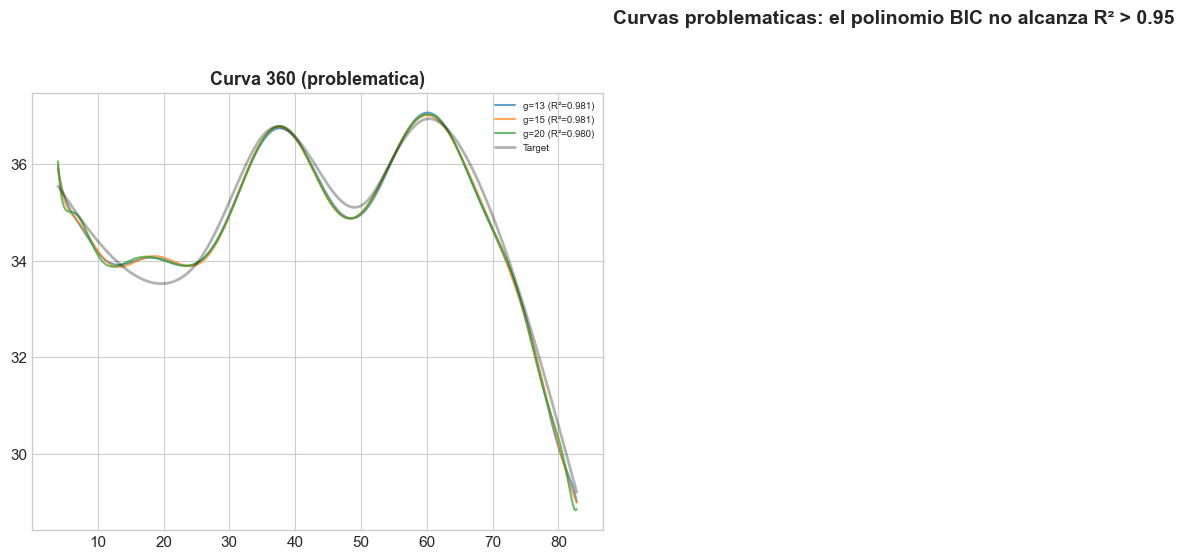

In [22]:
# Analisis detallado: curvas "problematicas" (R2 < 0.95 con su grado BIC)
problematicas = df_curvas[df_curvas['r2_min'] < 0.95]

print(f'Curvas con R² < 0.95 en alguna escala (con grado BIC): {len(problematicas)}')
if len(problematicas) > 0:
    print()
    print(problematicas[['curva', 'bic_X10', 'bic_X25', 'r2_min',
                         'r2_promedio', 'dificultad']].to_string(index=False))
    
    # Mostrar las primeras 6 problematicas
    n_show = min(6, len(problematicas))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i in range(n_show):
        ax = axes[i]
        cid = int(problematicas.iloc[i]['curva'])
        
        tx, ty = load_target(cid)
        px, py = load_pixel(cid, 10)
        mx, my = pixel_to_target(px, py, 10)
        
        idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
        xs_t, ys_t = tx[idx_t], ty[idx_t]
        
        # Ajustar con grado alto fijo
        for g_test in [int(problematicas.iloc[i]['bic_X10']), 15, 20]:
            coeffs = np.polyfit(mx, my, g_test)
            y_pred = np.poly1d(coeffs)(xs_t)
            r2 = r2_score(ys_t, y_pred)
            ax.plot(xs_t, y_pred, linewidth=1.5, alpha=0.7,
                    label=f'g={g_test} (R²={r2:.3f})')
        
        ax.plot(xs_t, ys_t, 'k-', linewidth=2, alpha=0.3, label='Target')
        ax.set_title(f'Curva {cid} (problematica)')
        ax.legend(fontsize=7)
    
    # Ocultar ejes sobrantes
    for j in range(n_show, 6):
        axes[j].set_visible(False)
    
    plt.suptitle('Curvas problematicas: el polinomio BIC no alcanza R² > 0.95',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Todas las curvas alcanzan R² >= 0.95 con su grado BIC.')

---

## 8. Conclusiones y recomendaciones

### Lo que encontramos

In [23]:
# Resumen final con numeros concretos
print('=' * 80)
print('RESUMEN FINAL DE APROXIMACIONES POLINOMIALES')
print('=' * 80)
print()
print(f'Total de curvas analizadas: 500')
print(f'Escalas evaluadas: X10, X15, X18, X21, X25')
print(f'Grados probados: 1 a 20')
print(f'Combinaciones evaluadas: {len(df_all):,}')
print()

# Grado BIC global
g_bic_x10 = df_curvas['bic_X10']
g_bic_x25 = df_curvas['bic_X25']
print('--- GRADO OPTIMO (criterio BIC)')
print(f'  Desde X10: media={g_bic_x10.mean():.1f}, mediana={g_bic_x10.median():.0f}, '
      f'rango=[{g_bic_x10.min():.0f}, {g_bic_x10.max():.0f}]')
print(f'  Desde X25: media={g_bic_x25.mean():.1f}, mediana={g_bic_x25.median():.0f}, '
      f'rango=[{g_bic_x25.min():.0f}, {g_bic_x25.max():.0f}]')
print()

print('--- DIFICULTAD')
for d in ['facil', 'media', 'dificil', 'muy_dificil']:
    n = (df_curvas['dificultad'] == d).sum()
    pct = n / 500
    barra = '|' * int(pct * 50)
    print(f'  {d:>15}: {n:>3} ({pct:>5.1%}) {barra}')
print()

print('--- CALIDAD (R² vs target)')
r2_all = df_curvas['r2_promedio']
print(f'  R² promedio global:   {r2_all.mean():.4f}')
print(f'  R² mediana global:    {r2_all.median():.4f}')
print(f'  Curvas con R² > 0.99: {(r2_all >= 0.99).sum()} ({(r2_all >= 0.99).mean():.1%})')
print(f'  Curvas con R² > 0.95: {(r2_all >= 0.95).sum()} ({(r2_all >= 0.95).mean():.1%})')
print(f'  Curvas con R² < 0.90: {(r2_all < 0.90).sum()} ({(r2_all < 0.90).mean():.1%})')
print()

print('--- CONCORDANCIA ENTRE CRITERIOS')
acuerdo_bic_aic = (df_master['g_bic'] == df_master['g_aic']).mean()
acuerdo_cercano = (np.abs(df_master['g_bic'] - df_master['g_aic']) <= 2).mean()
print(f'  BIC == AIC exacto:   {acuerdo_bic_aic:.1%}')
print(f'  |BIC - AIC| <= 2:    {acuerdo_cercano:.1%}')

RESUMEN FINAL DE APROXIMACIONES POLINOMIALES

Total de curvas analizadas: 500
Escalas evaluadas: X10, X15, X18, X21, X25
Grados probados: 1 a 20
Combinaciones evaluadas: 50,000

--- GRADO OPTIMO (criterio BIC)
  Desde X10: media=16.2, mediana=17, rango=[3, 20]
  Desde X25: media=17.8, mediana=19, rango=[6, 20]

--- DIFICULTAD
            facil:   0 ( 0.0%) 
            media:  25 ( 5.0%) ||
          dificil:  60 (12.0%) ||||||
      muy_dificil: 415 (83.0%) |||||||||||||||||||||||||||||||||||||||||

--- CALIDAD (R² vs target)
  R² promedio global:   0.9968
  R² mediana global:    0.9984
  Curvas con R² > 0.99: 468 (93.6%)
  Curvas con R² > 0.95: 499 (99.8%)
  Curvas con R² < 0.90: 0 (0.0%)

--- CONCORDANCIA ENTRE CRITERIOS
  BIC == AIC exacto:   69.2%
  |BIC - AIC| <= 2:    86.5%


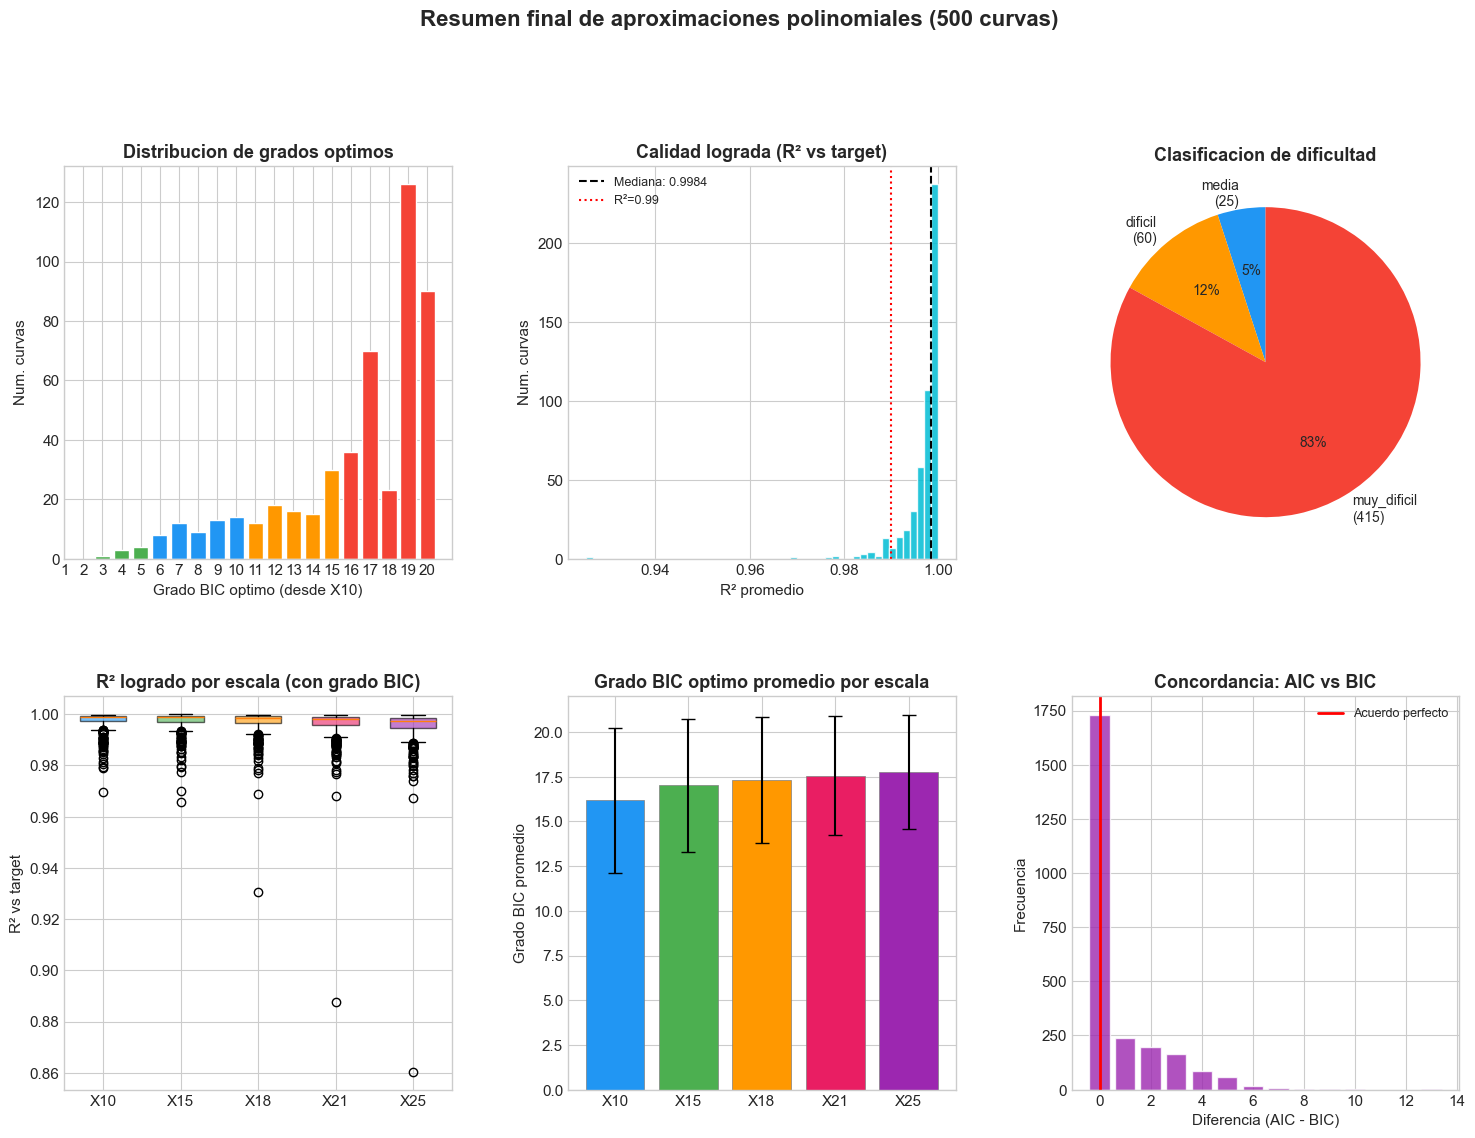

In [24]:
# Grafica resumen final
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

# Panel 1: Distribucion de grado BIC
ax1 = fig.add_subplot(gs[0, 0])
counts = g_bic_x10.value_counts().sort_index()
colores_barra = []
for g in counts.index:
    if g <= 5: colores_barra.append(C['verde'])
    elif g <= 10: colores_barra.append(C['azul'])
    elif g <= 15: colores_barra.append(C['naranja'])
    else: colores_barra.append(C['rojo'])

ax1.bar(counts.index, counts.values, color=colores_barra, edgecolor='white')
ax1.set_xlabel('Grado BIC optimo (desde X10)')
ax1.set_ylabel('Num. curvas')
ax1.set_title('Distribucion de grados optimos')
ax1.set_xticks(range(1, 21))

# Panel 2: R2 logrado
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(r2_all, bins=50, color=C['cyan'], edgecolor='white', alpha=0.85)
ax2.axvline(r2_all.median(), color='black', linestyle='--',
            label=f'Mediana: {r2_all.median():.4f}')
ax2.axvline(0.99, color='red', linestyle=':', label='R²=0.99')
ax2.set_xlabel('R² promedio')
ax2.set_ylabel('Num. curvas')
ax2.set_title('Calidad lograda (R² vs target)')
ax2.legend(fontsize=9)

# Panel 3: Pie chart de dificultad
ax3 = fig.add_subplot(gs[0, 2])
dif_sizes = []
dif_labels = []
dif_colors = []
for d, col in [('facil', C['verde']), ('media', C['azul']),
               ('dificil', C['naranja']), ('muy_dificil', C['rojo'])]:
    n = (df_curvas['dificultad'] == d).sum()
    if n > 0:
        dif_sizes.append(n)
        dif_labels.append(f'{d}\n({n})')
        dif_colors.append(col)

ax3.pie(dif_sizes, labels=dif_labels, colors=dif_colors, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 10})
ax3.set_title('Clasificacion de dificultad')

# Panel 4: R2 por escala (boxplot)
ax4 = fig.add_subplot(gs[1, 0])
r2_data = [df_curvas[f'r2_{e}'].dropna() for e in ['X10', 'X15', 'X18', 'X21', 'X25']]
bp = ax4.boxplot(r2_data, labels=['X10', 'X15', 'X18', 'X21', 'X25'],
                 patch_artist=True, widths=0.6)
for patch, escala in zip(bp['boxes'], ['X10', 'X15', 'X18', 'X21', 'X25']):
    patch.set_facecolor(SCALE_COLORS[escala])
    patch.set_alpha(0.6)
ax4.set_ylabel('R² vs target')
ax4.set_title('R² logrado por escala (con grado BIC)')

# Panel 5: Grado BIC promedio por escala
ax5 = fig.add_subplot(gs[1, 1])
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    col = f'bic_{escala}'
    ax5.bar(escala, df_curvas[col].mean(), color=SCALE_COLORS[escala],
            edgecolor='gray', linewidth=0.5, yerr=df_curvas[col].std(), capsize=5)
ax5.set_ylabel('Grado BIC promedio')
ax5.set_title('Grado BIC optimo promedio por escala')

# Panel 6: Concordancia BIC vs AIC
ax6 = fig.add_subplot(gs[1, 2])
diff_bic_aic = df_master['g_aic'] - df_master['g_bic']
counts_diff = diff_bic_aic.value_counts().sort_index()
ax6.bar(counts_diff.index, counts_diff.values, color=C['morado'],
        edgecolor='white', alpha=0.8)
ax6.set_xlabel('Diferencia (AIC - BIC)')
ax6.set_ylabel('Frecuencia')
ax6.set_title('Concordancia: AIC vs BIC')
ax6.axvline(0, color='red', linewidth=2, label='Acuerdo perfecto')
ax6.legend(fontsize=9)

fig.suptitle('Resumen final de aproximaciones polinomiales (500 curvas)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Conclusiones

**1. El grado importa, y ahora sabemos cual usar para cada curva.**

No todas las curvas son iguales. Algunas se aproximan perfecto con grado 4, otras necesitan grado 15+. Ahora tenemos una tabla con el grado recomendado (por BIC) para cada una de las 500 curvas, en cada escala.

**2. BIC es el criterio mas confiable para este dataset.**

Es conservador (prefiere modelos simples) pero logra R² muy altos. AIC tiende a dar grados un poco mas altos sin mejorar significativamente la calidad. La validacion cruzada confirma que BIC no se queda corto.

**3. Las curvas dificiles tienen rasgos geometricos identificables.**

Las curvas que necesitan grados altos tienden a tener: mas puntos de inflexion, mayor curvatura maxima, mas cambios de direccion, y mayor variabilidad en pendiente. Esto tiene sentido: un polinomio necesita mas "libertad" (mas grado) para capturar formas mas complejas.

**4. Incluso desde la peor resolucion (X10), la reconstruccion es buena.**

No hace falta la mejor escala para reconstruir bien. X10 (la resolucion mas baja) ya da resultados muy decentes si usas el grado correcto.

**5. Recomendacion practica:**

- Si no sabes nada de la curva: empieza con **grado 8-10** (cubre la mayoria de casos).
- Si la curva se ve "simple" (pocas ondulaciones): prueba **grado 4-6**.
- Si la curva tiene muchas oscilaciones: sube a **grado 12-15**.
- Siempre verifica con BIC o AIC: si agregar un grado mas no mejora el criterio, no lo hagas.

### Archivos generados

| Archivo | Contenido |
|---------|----------|
| `grados_optimos_por_curva.csv` | Grado BIC, AIC, R² para cada curva (500 filas) |
| `detalle_criterios_por_curva_escala.csv` | Todos los criterios, por curva x escala (2500 filas) |